## Sports Betting Market Tools:

The goal of this project is to show some toy models for a variety of different section with sports brtting markets ranging from estimating the profitability of a model to how a betting market can be manipulated. In detail, this notebook is splitted to the following sections:

1.   Using Betting Markets information: This section shows a model to estimate the ExG values for a game based on the market prices weighted by their liquidity.
2.   Model average ROI estimator: Based on a Bayesian mixture model the ROI of a model is calculated combined with the probability of the model being profitable at all given bets' prices and model's estimation data.
3.   Kelly Criterion Adjustments: Exploring variations and different applications of Kelly Criterion.
4.   Reactive Markets to liquidity: Betting Markets adjustment to liquidity model and manipulation.


In [2]:
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import poisson
from scipy.stats import norm
from scipy.stats import binom
from scipy.stats import beta

seed = 42
rng = np.random.default_rng(seed)

## Using Betting Markets information:

### Finding the ExGs prices for a game based on markets' prices:

Creating the score matrix probability for a large range of potential ExG home and away values within 0.3 and 3.2 values:

In [ ]:
exG_1 = np.linspace(0.2,3.2,200)
exG_2 = np.linspace(0.2,3.2,200)
rho = -0.13
goals = np.arange(11)

pmf_home = poisson.pmf(goals[:, None], exG_1[None, :])
pmf_away = poisson.pmf(goals[:, None], exG_2[None, :])

prob_score_matrix = (pmf_home.T[:, None, :, None]* pmf_away.T[None, :, None, :])

lam = exG_1[:, None]
mu = exG_2[None, :]

prob_score_matrix[:, :, 0, 0] *= (1 - lam * mu * rho)
prob_score_matrix[:, :, 0, 1] *= (1 + lam * rho)
prob_score_matrix[:, :, 1, 0] *= (1 + mu * rho)
prob_score_matrix[:, :, 1, 1] *= (1 - rho)

prob_score_matrix /= prob_score_matrix.sum(axis=(2, 3), keepdims=True)
print(prob_score_matrix.shape)

(200, 200, 11, 11)


Creating the main markets' probabilities matrices including home win, draw, over 2.5 goals, european handicap -1 and both teams to score for the same range of values of ExG home team and ExG away team:

In [ ]:
variables_prob_matrix = np.zeros((5,len(exG_1),len(exG_2)))

draw_prob = np.trace(prob_score_matrix, axis1=2, axis2=3)

lower_mask = np.tril(np.ones((11, 11), dtype=bool), k=-1)
home_win_prob =prob_score_matrix[..., lower_mask].sum(axis=-1)

upper_mask = np.triu(np.ones((11, 11), dtype=bool), k=1)
away_win_prob = prob_score_matrix[..., upper_mask].sum(axis=-1)

g = np.arange(11)
over25_mask = (g[:, None] + g[None, :]) >= 2.5
over25_prob = prob_score_matrix[..., over25_mask].sum(axis=-1)

hand_mask = (g[:, None] - g[None, :]) > 1.5
hand_prob = prob_score_matrix[..., hand_mask].sum(axis=-1)

btts_mask = (g[:, None] - g[None, :]) > 0
btts_prob = prob_score_matrix[..., btts_mask].sum(axis=-1)

variables_prob_matrix[0,:,:] = home_win_prob
variables_prob_matrix[1,:,:] = draw_prob
variables_prob_matrix[2,:,:] = hand_prob
variables_prob_matrix[3,:,:] = over25_prob
variables_prob_matrix[4,:,:] = btts_prob

Now that there is an ExG-markets probability matrix for estimating the market's exG values a function for mock data can be created for calculating the main markets prices given the ExGs and rho:

In [ ]:
def match_price(rho,exg_1,exg_2):

  total_goals_matrix = g[:, None] + g[None, :]
  handicap_matrix = g[:, None] - g[None, :]
  btts_matrix = g[:, None]*g[None, :]>0

  pmf_home = poisson.pmf(goals[:, None], exg_1)
  pmf_away = poisson.pmf(goals[:, None], exg_2)

  score_matrix = (pmf_home.T[:, None, :, None] *pmf_away.T[None, :, None, :])
  score_matrix = score_matrix[0,0,:,:]

  score_matrix[0, 0] *= (1 - exg_1 * exg_2 * rho)
  score_matrix[0, 1] *= (1 + exg_1 * rho)
  score_matrix[1, 0] *= (1 + exg_2 * rho)
  score_matrix[1, 1] *= (1 - rho)

  home_win = np.sum(np.tril(score_matrix, k=-1))
  draw = np.sum(np.diag(score_matrix))
  away_win = np.sum(np.triu(score_matrix, k=1))

  handicap_EU_1 = np.sum(score_matrix[handicap_matrix>1.5])
  over_25 = np.sum(score_matrix[total_goals_matrix>2.5])
  btts = np.sum(score_matrix[btts_matrix])

  return [home_win, draw, handicap_EU_1, over_25, btts]


prices_example = match_price(rho,2,1)
prices_example

[np.float64(0.5927501951077261),
 np.float64(0.23760135951316785),
 np.float64(0.36723139439778835),
 np.float64(0.576801600601105),
 np.float64(0.5595117212481572)]

Now based on the above simulated markets' prices the ExGs combination with the best fit to the previously calculated prices matrix can be estimated:

In [ ]:
for i in range(0,5):
  mar_prob_diff += np.abs(variables_prob_matrix[i]-prices_example[i])

idx = np.unravel_index(np.argmin(mar_prob_diff), mar_prob_diff.shape)
print("ExG home:",np.round(exG_1[idx[0]],2),", ExG away:",np.round(exG_2[idx[1]],2))

ExG home: 1.99 , ExG away: 1.0


Below a function form for the above process is shown:

In [ ]:
def create_markets_prices_matrix_inv(exG_1,exG_2,rho,max_goals = 11):
  goals = np.arange(max_goals)

  pmf_home = poisson.pmf(goals[:, None], exG_1[None, :])
  pmf_away = poisson.pmf(goals[:, None], exG_2[None, :])

  prob_score_matrix = (pmf_home.T[:, None, :, None]* pmf_away.T[None, :, None, :])

  lam = exG_1[:, None]
  mu = exG_2[None, :]

  prob_score_matrix[:, :, 0, 0] *= (1 - lam * mu * rho)
  prob_score_matrix[:, :, 0, 1] *= (1 + lam * rho)
  prob_score_matrix[:, :, 1, 0] *= (1 + mu * rho)
  prob_score_matrix[:, :, 1, 1] *= (1 - rho)

  prob_score_matrix /= prob_score_matrix.sum(axis=(2, 3), keepdims=True)
  print(prob_score_matrix.shape)

  variables_prob_matrix = np.zeros((5,len(exG_1),len(exG_2)))

  draw_prob = np.trace(prob_score_matrix, axis1=2, axis2=3)

  lower_mask = np.tril(np.ones((max_goals, max_goals), dtype=bool), k=-1)
  home_win_prob =prob_score_matrix[..., lower_mask].sum(axis=-1)

  upper_mask = np.triu(np.ones((max_goals, max_goals), dtype=bool), k=1)
  away_win_prob = prob_score_matrix[..., upper_mask].sum(axis=-1)

  g = np.arange(max_goals)
  over25_mask = (g[:, None] + g[None, :]) >= 2.5
  over25_prob = prob_score_matrix[..., over25_mask].sum(axis=-1)

  hand_mask = (g[:, None] - g[None, :]) > 1.5
  hand_prob = prob_score_matrix[..., hand_mask].sum(axis=-1)

  btts_mask = (g[:, None] - g[None, :]) > 0
  btts_prob = prob_score_matrix[..., btts_mask].sum(axis=-1)

  variables_prob_matrix[0,:,:] = home_win_prob
  variables_prob_matrix[1,:,:] = draw_prob
  variables_prob_matrix[2,:,:] = hand_prob
  variables_prob_matrix[3,:,:] = over25_prob
  variables_prob_matrix[4,:,:] = btts_prob

  return variables_prob_matrix


def ExG_from_prices(prices_list,variables_prob_matrix,exG_1,exG_2,rho=-0.13,max_goals = 11):
  if variables_prob_matrix == None:
    variables_prob_matrix = create_markets_prices_matrix_inv(exG_1,exG_2,rho,max_goals)

  for i in range(0,5):
    mar_prob_diff += np.abs(variables_prob_matrix[i]-prices_list[i])

  idx = np.unravel_index(np.argmin(mar_prob_diff), mar_prob_diff.shape)
  return np.round(exG_1[idx[0]],2), np.round(exG_2[idx[1]],2)

### ExGs estimations from an inefficient market based on liquidity:

An approach further deeper than finding the ExG values based on the assumption that betting markets are efficient can be the combination of the information of each of the main markets based on their liquidity. Such models can be extremely usefull for arbitrage in exchanges especially at times of high volatility due to news or time coming closer (and more participants to be added in the market). This approach can be tried woth any model or set of free parameters but here it is just shown as the simplest case looking for the ExG of the home and away team with a Dixon-Coles model given its ρ parameter.

We treat each market price as observation of the mean of a Guassian and the posterior ExGs probability is the mixture of these gaussians weighted by their liquidity. A different model could use the liquidity as a parameter of a standard deviation of the Guassian of each market and the tau parameter could be ignored in that case fully.

Given the markets prices given the ExGs of a game the likelikood is calculated be summing the squared difference of the given price and the matrix devided by a free parameter τ weighted by its market liquidity:

$$ L_i(h,a) = \exp\left( -\lambda_i \cdot \frac{(P_i(h,a) - p_i)^2}{2\tau^2} \right) $$

Assuming conditional independence the posterior probability is given by:

$$ \log P(h,a) = \sum_{i=1}^{N} \log L_i(h,a) $$

$$ P(h,a) = \frac{\exp(\log P(h,a))}
{\sum_{h',a'} \exp(\log P(h',a'))} $$

The home and away ExG distributions are given by sibmply the marginal distributions of each based on the previously calculated joint posterior distribution:

$$ \mathbb{E}[H] = \sum_{h \in \mathcal{H}} \sum_{a \in \mathcal{A}}
h \cdot P(h,a) $$

$$
\mathbb{E}[A] = \sum_{h \in \mathcal{H}} \sum_{a \in \mathcal{A}}
a \cdot P(h,a)
$$

In [ ]:
def combine_exG(variables_prob_matrix, prices_example, liq, home_vals, away_vals, tau=0.15):
    log_post = 0

    for i in range(len(liq)):
        diff = variables_prob_matrix[i] - prices_example[i]

        # stable Gaussian likelihood
        log_post += liq[i] * (-(diff**2) / (2 * tau**2))

    post = np.exp(log_post - np.max(log_post))  # numerical stability
    post /= post.sum()

    home_exG_dist = post.sum(axis=1)
    away_exG_dist = post.sum(axis=0)

    H, W = post.shape

    exG_home = np.sum(post * home_vals[:, None])
    exG_away = np.sum(post * away_vals[None, :])

    std_home = np.sqrt(np.sum(home_exG_dist * (home_vals - exG_home)**2))
    std_away = np.sqrt(np.sum(away_exG_dist * (home_vals - exG_away)**2))

    return np.round(exG_home,2), np.round(exG_away,2), np.round(std_home,2), np.round(std_away,2), home_exG_dist, away_exG_dist

The prices of a football match are calculated with ExG values of 2 and 1 for home and away respectively based on a Dixon-Coles model with fixed ρ parameter of -0.13. The goal of this section is to estimate the ExG values that led to these prices with high accuracy and precision through the toy model explained above given that ρ is fixed and we know its value.

The free parameter τ in the toy model quantifies how sharp is the market before the additional liquidity, small τ means extremely accurate values while large τ means high uncertainty. Below the ExG values' estimation is shown for two different τ values for demonstrating its usage. A typical standard deviation in ExG values in spread betting exchanges is the 0.05 can be opbtained for the values pre liquidity information with using τ=0,02.

Generally the below results should be similar to the direct estimation as shown before with assuming that the market is efficient with the difference of uncertainty through τ and the models' processes.

In [ ]:
prices_example = match_price(-0.13,2,1)

τ = 0.2 : Home ExG 2.17 +- 0.5 , Away ExG 1.31 +- 0.59
τ = 0.02 : Home ExG 1.98 +- 0.05 , Away ExG 1.03 +- 0.05


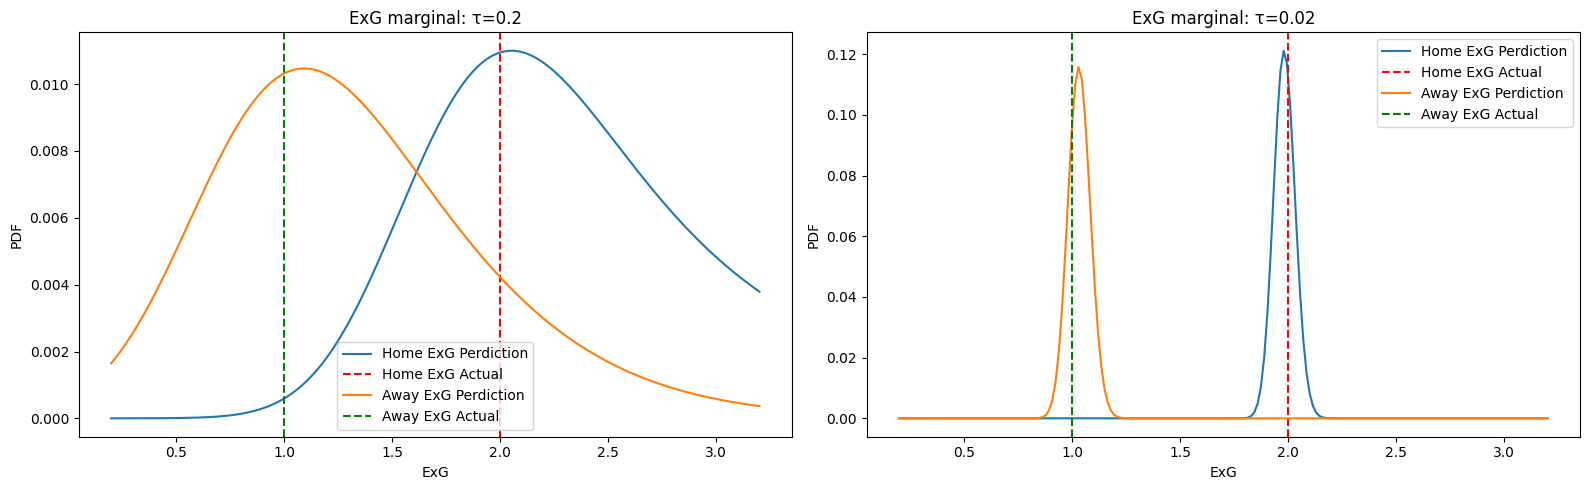

In [ ]:
fig, axes = plt.subplots(1,2,figsize = (16,5))
liq = np.array([1, 1, 1, 1, 1], dtype=float)

exG_home, exG_away, std_home, std_away, home_exG_dist, away_exG_dist = combine_exG(variables_prob_matrix, prices_example, liq, exG_1, exG_2, tau=0.2)
print("τ = 0.2 : Home ExG",exG_home,"+-", std_home,", Away ExG",exG_away,"+-", std_away)

axes[0].plot(exG_1, home_exG_dist,label = 'Home ExG Perdiction')
axes[0].axvline(2, color='r', linestyle='--',label = 'Home ExG Actual')
axes[0].plot(exG_2, away_exG_dist,label = 'Away ExG Perdiction')
axes[0].axvline(1, color='g', linestyle='--',label = 'Away ExG Actual')
axes[0].set_xlabel("ExG")
axes[0].set_ylabel("PDF")
axes[0].set_title("ExG marginal: τ=0.2")
axes[0].legend()


exG_home, exG_away, std_home, std_away, home_exG_dist, away_exG_dist = combine_exG(variables_prob_matrix, prices_example, liq, exG_1, exG_2, tau=0.02)
print("τ = 0.02 : Home ExG",exG_home,"+-", std_home,", Away ExG",exG_away,"+-", std_away)

axes[1].plot(exG_1, home_exG_dist,label = 'Home ExG Perdiction')
axes[1].axvline(2, color='r', linestyle='--',label = 'Home ExG Actual')
axes[1].plot(exG_2, away_exG_dist,label = 'Away ExG Perdiction')
axes[1].axvline(1, color='g', linestyle='--',label = 'Away ExG Actual')
axes[1].set_xlabel("ExG")
axes[1].set_ylabel("PDF")
axes[1].set_title("ExG marginal: τ=0.02")
axes[1].legend()

plt.tight_layout()

Below different combinations of markets with much higher liquidity than the rest are being explored with the target being the accurate and precise estimation of the ExG values that led to the given prices. The τ parameters is fixed at 0.2 essentially assuming that the prices are far from accurate before the extra liquidity have been added with high variance on both of the ExGs' values estimations. The liquidity values of the markets with high liquidity is assigned to 100 while the rest of the markets have values of 1.

As it cen be seen the best combinations in both terms of accuracy and precision are the home win & Over and EH-1 & Over and is not a suprise since they are the two markets that capture all the information that the DC model needs and the home win and EH-1 are essentially the same market. The reason for using the handicap as well in this model is that in rare cases of extreme ExG difference between the teams the match result market ends up giving to the favourite extremely low prices and so the liquidity in practice tends to be very small with the handicap markets replacing it.

The combinations of Draw & Over (with less precision) and the Over & BTTS manage to lead to the expected ExG estimations but with higher variance than the previously discussed group of combinations. The worst performed markets' combination was the Home win & BTTS with the Draw & BTTS following closely in terms of bad performance. Especially the first case added litle to none information to the estimator compared to the τ=0.2 plot of marginals without liquidity information. The match result and BTTS only seems to be a weak combination of market information for deriving the ExG values that generated the market prices. The reason though for including the BTTS (and the draw as well) is that it can include information on the ρ parameter of the DC model that could be added as well in future similar model approaches figuiring out a tougher parameter to be estimated than ExGs.


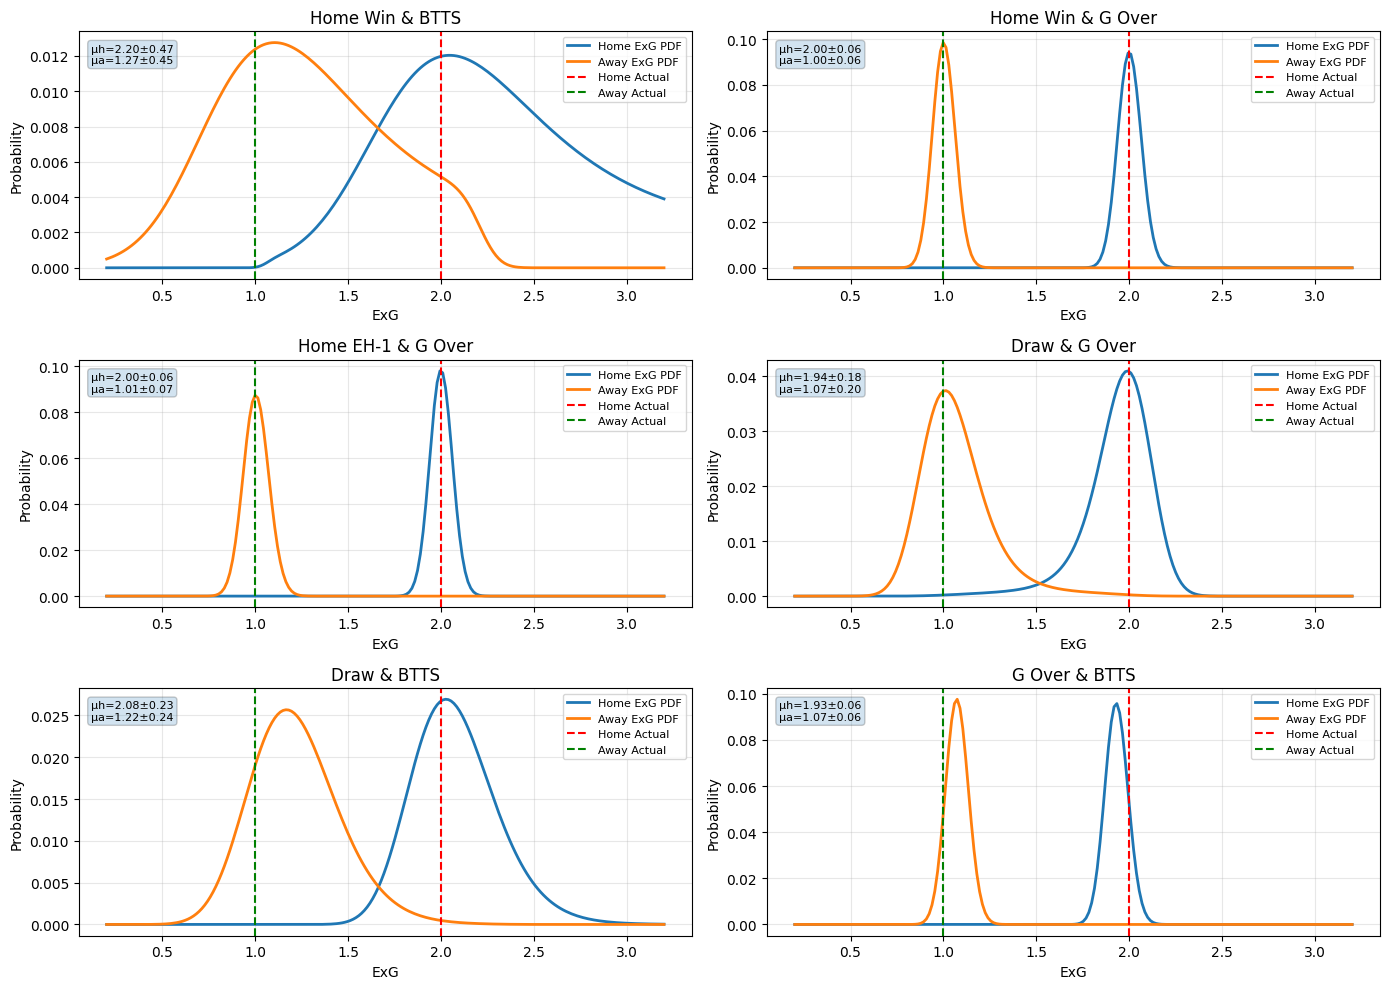

In [ ]:
def plot_exG_panel(ax, exG_1, exG_2, home_dist, away_dist, title):

    home_dist = home_dist / np.sum(home_dist)
    away_dist = away_dist / np.sum(away_dist)

    ax.plot(exG_1, home_dist, label=r"Home ExG PDF", lw=2)
    ax.plot(exG_2, away_dist, label=r"Away ExG PDF", lw=2)

    ax.axvline(2, color='red', linestyle='--', lw=1.5, label="Home Actual")
    ax.axvline(1, color='green', linestyle='--', lw=1.5, label="Away Actual")

    ax.set_title(title)
    ax.set_xlabel("ExG")
    ax.set_ylabel("Probability")

    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)


fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.ravel()

scenarios = [
    ("Home Win & BTTS",       [100, 1, 1, 1, 100]),
    ("Home Win & G Over",     [100, 1, 1, 100, 1]),
    ("Home EH-1 & G Over",    [1, 1, 100, 100, 1]),
    ("Draw & G Over",         [1, 100, 1, 100, 1]),
    ("Draw & BTTS",           [1, 100, 1, 1, 100]),
    ("G Over & BTTS",         [1, 1, 1, 100, 100]),
]

for ax, (title, liq) in zip(axes, scenarios):

    liq = np.array(liq, dtype=float)

    exG_home, exG_away, std_home, std_away, home_dist, away_dist = combine_exG(
        variables_prob_matrix,
        prices_example,
        liq,
        exG_1,
        exG_2,
        tau=0.2
    )

    plot_exG_panel(ax, exG_1, exG_2, home_dist, away_dist, title)

    ax.text(
        0.02, 0.95,
        f"μh={exG_home:.2f}±{std_home:.2f}\nμa={exG_away:.2f}±{std_away:.2f}",
        transform=ax.transAxes,
        fontsize=8,
        va='top',
        bbox=dict(boxstyle="round", alpha=0.2)
    )

plt.tight_layout()
plt.show()

Now let's assume that there is a market imbalance based on the Dixon Coles Model and the win probability, based on the other markets, instead of being 60% is 70%. Four scenarios of liquidity distribution are explored in order to check how the model reacts and to verify that the basic expectations for the model are met. For this case the τ parameter is fixed at 0.20 as well.

The best combination of markets is the home win or EH-1 with the over markets as being shown before, the results on these combinations are interesting. For the high liquidity combination of handicap and over the match result is ignored and the initial ExG values are estimated with high accuracy and precision. For the case of combining the offset home win price and over with high liquidity the ExGs are adjusted to the appropriate values (higher home ExG and lower away ExG) that result at the higher home win probability but also keep constant the toal ExG sum based on the price of the over.

The other scenarios that are being shown are the Home win & Draw and Draw & Over. For the first case the total sum of ExG is getting lower leading to a larger decrease to the away team than the home one for explaining the larger home win probability but the standard deviation of this value is extremely large. This is also expected since the home win and the draw are highly correlated. The latter case ExGs' values very close to the original ones (within one standard deviation) performing better than expected.

In [ ]:
prices_example[0] = 0.7

Home Win & Draw: Home ExG 1.93 ± 0.23, Away ExG 0.56 ± 0.20
Home Win & G Over: Home ExG 2.24 ± 0.07, Away ExG 0.76 ± 0.06
Home EH-1 & G Over: Home ExG 2.00 ± 0.06, Away ExG 1.00 ± 0.07
Draw & G Over: Home ExG 1.93 ± 0.06, Away ExG 1.07 ± 0.06


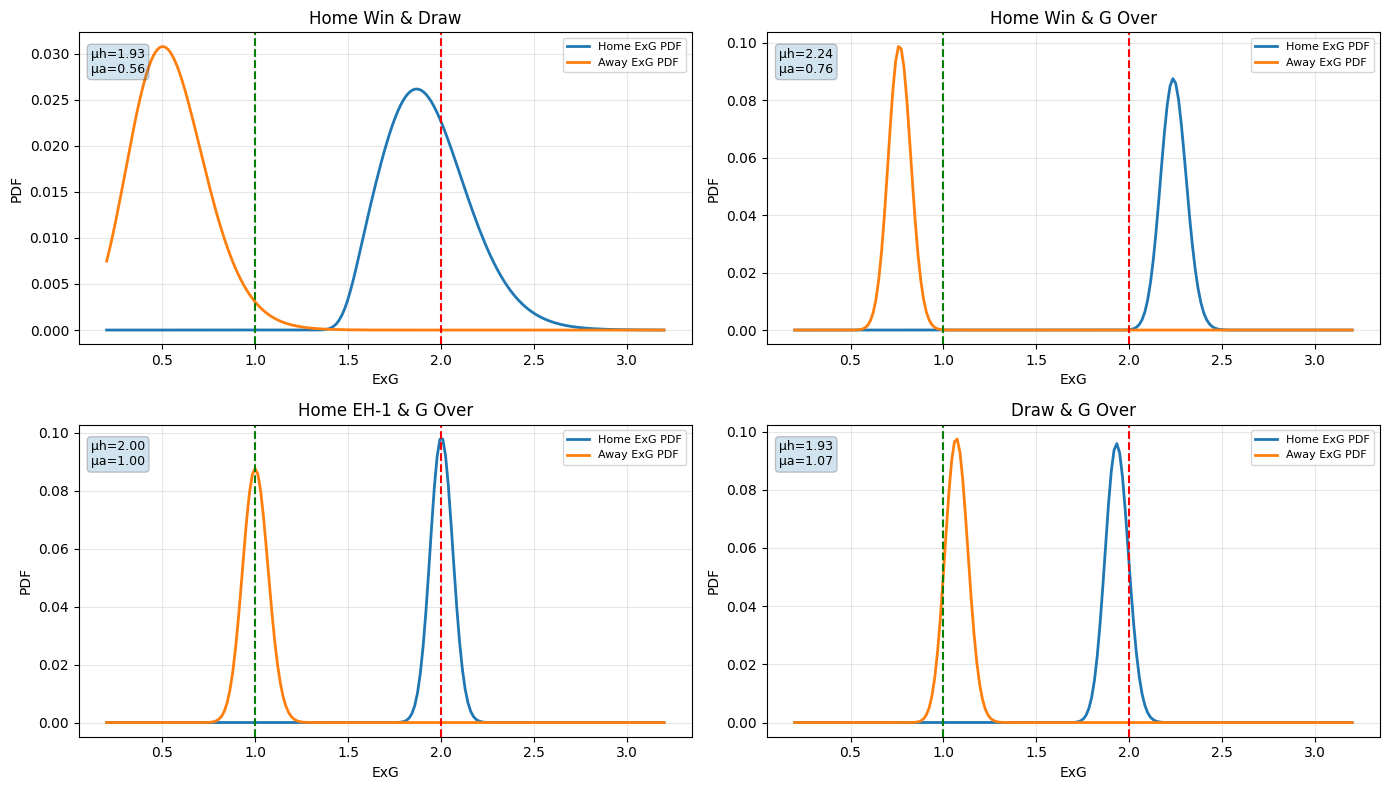

In [ ]:
def plot_exG(ax, exG_1, exG_2, home_dist, away_dist, title):

    home_dist = home_dist / np.sum(home_dist)
    away_dist = away_dist / np.sum(away_dist)

    ax.plot(exG_1, home_dist, label=r"Home ExG PDF", lw=2)
    ax.plot(exG_2, away_dist, label=r"Away ExG PDF", lw=2)

    ax.axvline(2, color='red', linestyle='--', lw=1.5)
    ax.axvline(1, color='green', linestyle='--', lw=1.5)

    ax.set_title(title)
    ax.set_xlabel("ExG")
    ax.set_ylabel("PDF")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

scenarios = [
    ("Home Win & Draw",    [100, 100, 1, 1, 1]),
    ("Home Win & G Over",  [100, 1, 1, 100, 1]),
    ("Home EH-1 & G Over", [1, 1, 100, 100, 1]),
    ("Draw & G Over",      [1, 1, 1, 100, 100]),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for ax, (title, liq) in zip(axes, scenarios):

    liq = np.array(liq, dtype=float)

    exG_home, exG_away, std_home, std_away, home_dist, away_dist = combine_exG(
        variables_prob_matrix,
        prices_example,
        liq,
        exG_1,
        exG_2,
        tau=0.2
    )

    print(f"{title}: Home ExG {exG_home:.2f} ± {std_home:.2f}, "
          f"Away ExG {exG_away:.2f} ± {std_away:.2f}")

    plot_exG(ax, exG_1, exG_2, home_dist, away_dist, title)

    ax.text(
        0.02, 0.95,
        f"μh={exG_home:.2f}\nμa={exG_away:.2f}",
        transform=ax.transAxes,
        fontsize=9,
        va='top',
        bbox=dict(boxstyle="round", alpha=0.2)
    )

plt.tight_layout()
plt.show()

Overall the toy model performed as expected and can be used as the basis for a more complicated approach by optimizing the τ value based on opening lines uncertainty and fitting a function between liquidity and market uncertaintity based on pricing data.

## Model average ROI estimator:

### Estimation without the market efficiency assumption:

Having a model is important but even more important is to have a very accurate one. So there is the question how to decide how good a model is and most importantly if it is profitable at all. For this reason a statistical model is explained below with the target to calculate the actual ROI of a model and the significance of the assumption that the model is profitable.

The model is simple, the bets can end up as wins or losses and the variable of each observation is the loss which is -1 (unit of money) or win with profit of price - 1 (the price are the inverse of the probability of an event). The statistical distribution resulting is a Bayessian mixture model containing a delta function at -1 and a gaussian distribution around the mean profit of the winning bets. The Gaussian component is expected since no model is perfect having its own noise so some randomness is expected and the odds values can vary while the probability of them leading to winning varies as well.

The main variables are θ being a Gaussian distribution with mean μ and variance σ, the $σ_{y}$ being the noise of the measurement and w being the weight parameter of the mixture (being 1 for the Gaussian component):


$$  \theta \sim \mathcal{N}(\mu_0, \sigma_0^2) $$
$$ y \sim w \cdot \mathcal{N}(\theta, \sigma_y^2) + (1 - w)\cdot \delta_{-1} \\ $$

The posterior probability γ of an observation belonging to the Guassian component calculated as:

If $y \neq -1$:

$$γ = 1$$


If $y = -1$:

$$
\gamma = \frac{
w \cdot \mathcal{N}(-1 \mid \mu_0, \sigma_0^2 + \sigma_y^2)
}{(1-w) + w \cdot \mathcal{N}(-1 \mid \mu_0, \sigma_0^2 + \sigma_y^2)} \\
$$



The mean and variance estimators of the Gaussian component are updated by a precision weighted Bayesian update:

$$
\sigma_1^2 =
\left( \frac{1}{\sigma_0^2} + \frac{\gamma}{\sigma_y^2} \right)^{-1}
$$

$$
\mu_1 = \sigma_1^2 \left( \frac{\mu_0}{\sigma_0^2} +
\frac{\gamma y}{\sigma_y^2} \right) \\
$$

For the weight variable of the mixture a Beta prior is used:

$$ w \sim \text{Beta}(a, b) \\ $$

The Beta parameters and the weight variable are updated as:

$$ a' = a + \gamma $$
$$ b' = b + (1 - \gamma) $$
$$ w = \frac{a'}{a' + b'} $$

In [2]:
def update_theta_w(mu0, sigma0, y, sigma_y, w, a, b):

    if y != -1:
        gamma = 1.0
    else:
        spike_lik = norm.pdf(-1,loc=mu0,scale=np.sqrt(sigma0**2 + sigma_y**2))

        gamma = (w * spike_lik) / ((1 - w) + w * spike_lik)

    precision = 1/sigma0**2 + gamma/sigma_y**2
    sigma1 = np.sqrt(1 / precision)

    mu1 = sigma1**2 * (mu0/sigma0**2 +gamma * y / sigma_y**2)

    a1 = a + gamma
    b1 = b + (1 - gamma)

    w1 = a1 / (a1 + b1)

    return mu1, sigma1, w1, a1, b1

At this stage 10000 events probability values are simulated as mock data for the Bayesian mixture model, the probability of the events happening follow a normal distribution with mean 0.50 and standard deviation of 0.1 and the prices for these events are 1/p. These prices are the fair values without any margin.

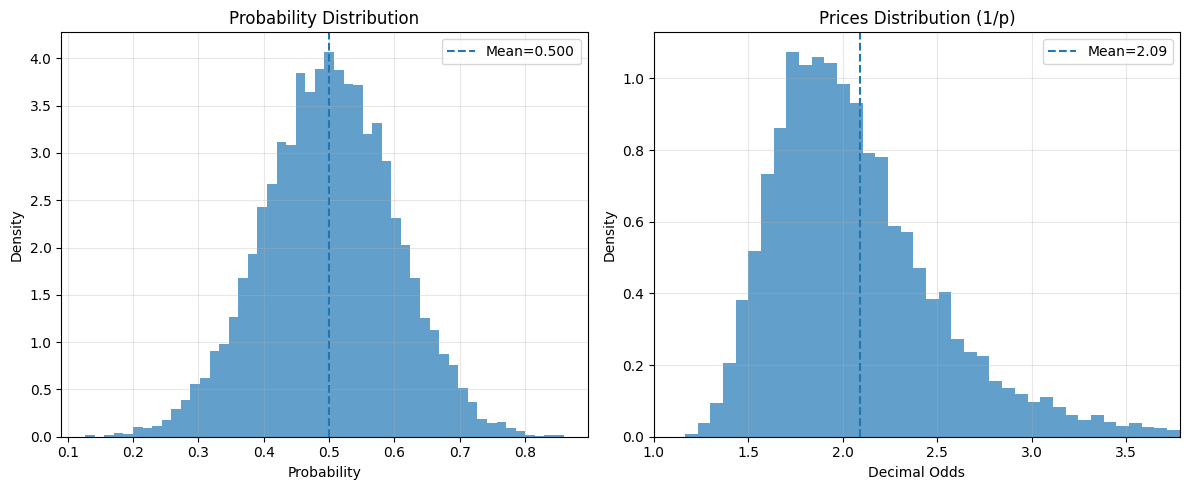

In [3]:
odds = norm.rvs(loc=0.5, scale=0.1, size=10000)
odds = np.clip(odds, 1e-3, 1)
prices = 1 / odds

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].hist(odds, bins=50, density=True, alpha=0.7)
ax[0].axvline(np.mean(odds), linestyle="--", label=f"Mean={np.mean(odds):.3f}")
ax[0].set_title("Probability Distribution")
ax[0].set_xlabel("Probability")
ax[0].set_ylabel("Density")
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].hist(prices, bins=100, density=True, alpha=0.7)
ax[1].axvline(np.mean(prices), linestyle="--", label=f"Mean={np.mean(prices):.2f}")
ax[1].set_title("Prices Distribution (1/p)")
ax[1].set_xlabel("Decimal Odds")
ax[1].set_ylabel("Density")
ax[1].set_xlim(1, np.percentile(prices, 99))
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Below the results are simulated by a binomial distribution based on the given simulated probabilities from the previous step. Two cases are explored, one with margin and one with value prices. The returns of all bets are either the marginated or value price -1 (our stake) in case of a win or -1 in case of a lose.

In [4]:
results_simulations = binom.rvs(n= 1, p = odds, size = odds.shape)

marginated_prices_return = prices/1.05 - 1
marginated_prices_return[results_simulations==0] = -1

value_prices_return = prices/0.95 - 1
value_prices_return[results_simulations==0] = -1
marginated_mean_roi = np.round(np.mean(marginated_prices_return),3)
value_mean_roi = np.round(np.mean(value_prices_return),3)
print('Mean ROI: Marginated Prices:',marginated_mean_roi,', Value Prices:',value_mean_roi)

Mean ROI: Marginated Prices: -0.053 , Value Prices: 0.046


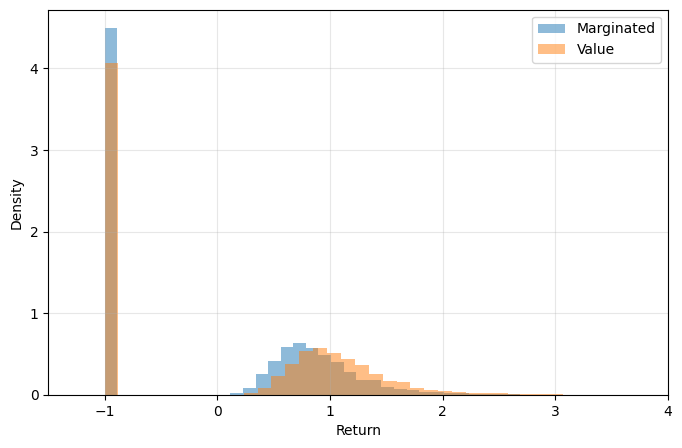

In [5]:
plt.figure(figsize=(8,5))

plt.hist(marginated_prices_return,bins=50,alpha=0.5,density=True,label="Marginated")
plt.hist(value_prices_return,bins=50,alpha=0.5,density=True,label="Value")

plt.xlabel("Return")
plt.ylabel("Density")
plt.legend()
plt.xlim(-1.5,4)
plt.grid(alpha=0.3)

plt.show()

The mixture model can estimate the mean and the standard deviation of the Gaussian component and the weight of the mixture. The ROI estimation is performed as follows:

$$ μ_{ROI} = (w \cdot (σ{0}^{2} + μ_{0}^{2}) + (1 - w) \cdot (-1)^{2}),  σ_{ROI} = σ_{0}^{2}$$

Another important metric for a model beside its ROI is how sure are we that it is profitable, this can be measured by the significance of rejecting the hypothesis that the ROI is negative. This can be done by assuming that the ROI is a normal distribution as Θ plus a constant $(1-w) \cdot (-1) $ that is the delta component:

$$  \theta_{ROI} \sim \mathcal{N}(\mu_0 - (1-w), \sigma_0^2) , H_{0} : \theta_{ROI} < 0 $$
$$P(\theta_{ROI} < 0) = \Phi(Z), Z = \frac{\bar \theta_{ROI}}{\sigma_0}
\\ $$

An important note to add is that the the prior belief effects will not be discussed further. Since the model is a Bayessian model the defined prior can make converging to the ROI value faster if it being picked in a smart way but at the opposite case can have the contrary results. For judging a model the two cases that are suggested as priors are the non informative one and the backtested one. In the case of no information in the prior from our part the expected margins should be assigned as ROI while for the backtested case the ROI can be assumed to be zero given that the market having adjusted to your models' value. Assuming as a prior a winning model already can be dangerous especially combine with the Kelly Criterion leading to big losses too early.

In [6]:
def roi_estimation(observations,mu_0, sigma_0):
  mu_upd = np.zeros(len(observations))
  sigma_upd = np.zeros(len(observations))
  w_upd = np.zeros(len(observations))
  sigma_y = np.std(observations)

  mu, sigma, w, a , b = mu_0, sigma_0, 0.5, 1, 1
  for i in range(0,len(observations)):
    mu, sigma, w, a, b = update_theta_w(mu, sigma, observations[i], sigma_y=sigma_y, w=w,a=a,b=b)
    mu_upd[i] = np.round(mu,2)
    sigma_upd[i] = np.round(sigma,2)
    w_upd[i] = np.round(w,2)


  roi = w_upd*mu_upd+(-1)*(1-w_upd)
  sigma_roi = sigma_upd
  winning_rate = w_upd
  roi_negative_p = norm.cdf(roi / sigma_roi)

  print('ROI = ',np.round(100*roi[-1],4),'+-',np.round(100* sigma_roi[-1],4),'100%, Negative ROI Rejection Significance = ',np.round(100*roi_negative_p[-1],3),'%')

  return roi, sigma_roi, winning_rate, roi_negative_p

Below the cases of a losing model paying the margin and a value model that beats the market. The model converges to the real ROI values as it can be seen, the estimation after the first 1000 observations is very close to the real ROI while after around 2000 observations the estimation is getting steady with very small standard deviation as well.

For rejecting the negative ROI hypothesis for the value case the level of 95% significance is reached after around 2000 observations while for the losing modelafter 1000 observations it seems very clearly that is very improbable to reject the null hypothesis.

ROI =  4.76 +- 1.0 100%, Negative ROI Rejection Significance =  100.0 %


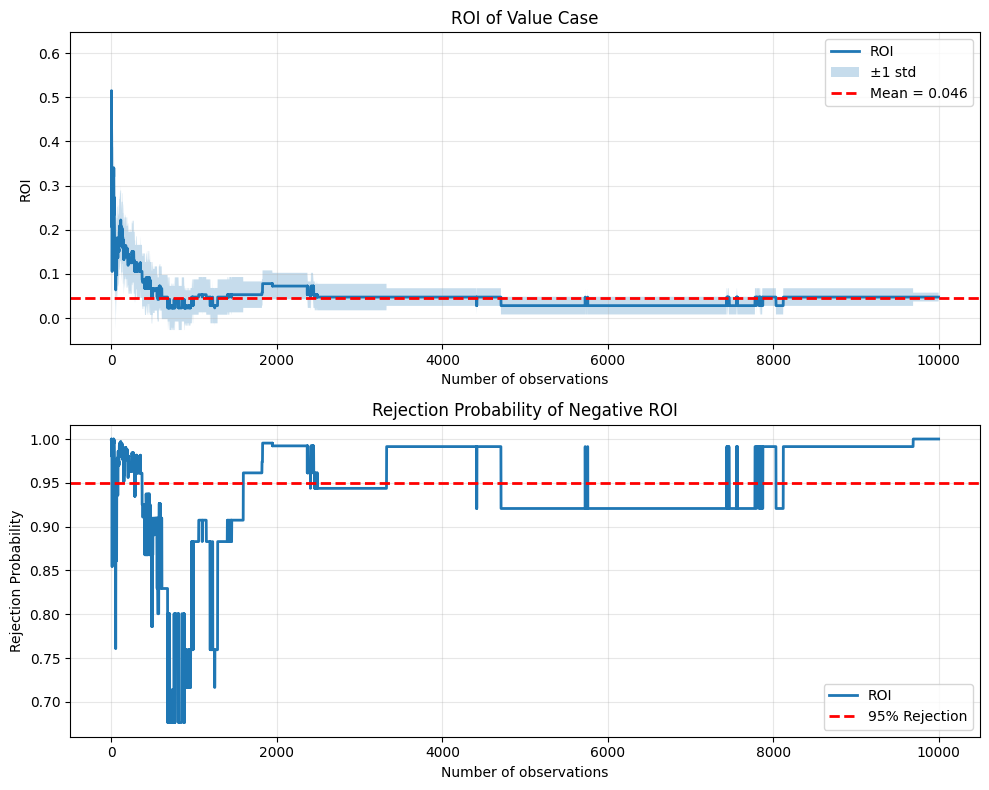

In [7]:
roi_value, sigma_roi_value, winning_rate_value, roi_negative_value = roi_estimation(value_prices_return, 1, 0.1)

no_observation = np.arange(len(value_prices_return))

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].plot(no_observation, roi_value, lw=2, label="ROI")

axes[0].fill_between(no_observation,
    roi_value - sigma_roi_value,
    roi_value + sigma_roi_value,
    alpha=0.25,label="±1 std")

axes[0].axhline(value_mean_roi,color='r',linestyle='--',linewidth=2,label=f"Mean = {value_mean_roi:.3f}")

axes[0].set_xlabel("Number of observations")
axes[0].set_ylabel("ROI")
axes[0].set_title("ROI of Value Case")
axes[0].grid(alpha=0.3)
axes[0].legend()


axes[1].plot(no_observation, roi_negative_value, lw=2, label="ROI")
axes[1].axhline(0.95,color='r',linestyle='--',linewidth=2,label = '95% Rejection')

axes[1].set_xlabel("Number of observations")
axes[1].set_ylabel("Rejection Probability")
axes[1].set_title("Rejection Probability of Negative ROI")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

ROI =  -5.5 +- 1.0 100%, Negative ROI Rejection Significance =  0.0 %


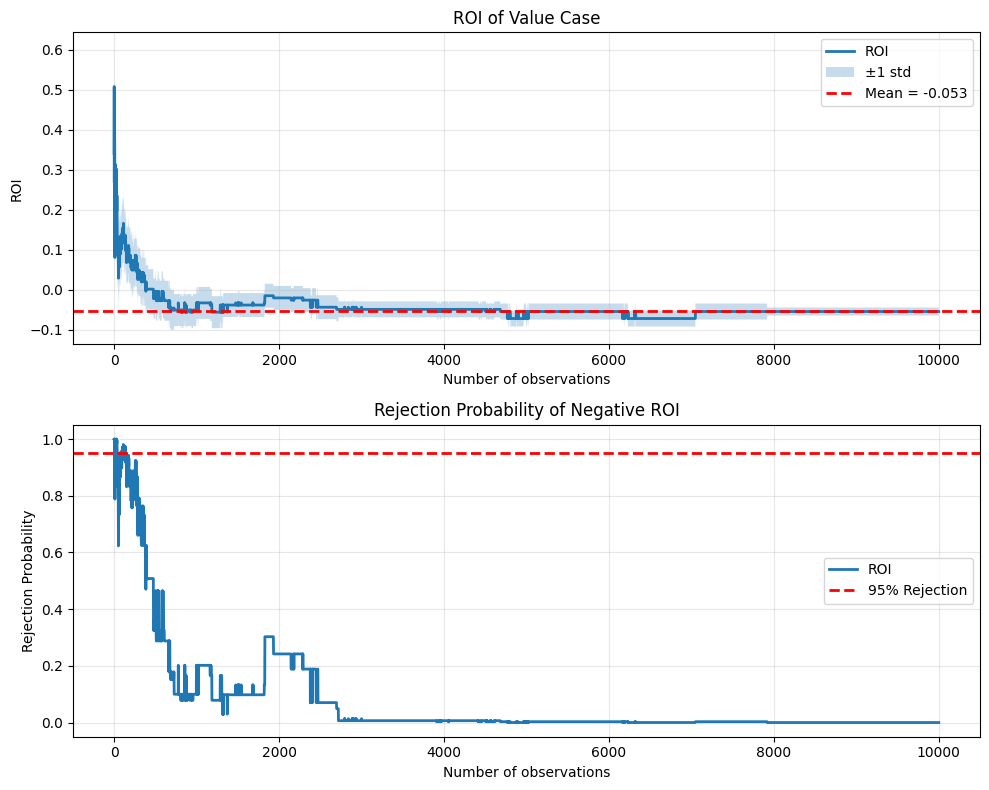

In [8]:

roi_margin, sigma_roi_margin, winning_rate_margin, roi_negative_marginated = roi_estimation(marginated_prices_return, 1, 0.1)

no_observation = np.arange(len(marginated_prices_return))

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].plot(no_observation, roi_margin, lw=2, label="ROI")

axes[0].fill_between(no_observation,
    roi_margin - sigma_roi_margin,
    roi_margin + sigma_roi_margin,
    alpha=0.25,label="±1 std")

axes[0].axhline(marginated_mean_roi,color='r',linestyle='--',linewidth=2,label=f"Mean = {marginated_mean_roi:.3f}")

axes[0].set_xlabel("Number of observations")
axes[0].set_ylabel("ROI")
axes[0].set_title("ROI of Value Case")
axes[0].grid(alpha=0.3)
axes[0].legend()


axes[1].plot(no_observation, roi_negative_marginated, lw=2, label="ROI")
axes[1].axhline(0.95,color='r',linestyle='--',linewidth=2,label = '95% Rejection')

axes[1].set_xlabel("Number of observations")
axes[1].set_ylabel("Rejection Probability")
axes[1].set_title("Rejection Probability of Negative ROI")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

### Estimation considering the market efficiency assumption:



A simpler version of estoimating the profitability model is by the closing lines, assuming that the betting markets operate according to the market efficiency theory the closing lines converge to the true probanbility of an event. For this case under the mentioned market assumption there is no need for the actual results since the true probability is known by the market. For judging the accuracy and precision of a model the agreement with the closing lines is needed.

For this reason some closing lines are simulated by their probability following a normal distribution with  mean 0.5 and std 0.01 while the model estimated prices are the same with some white noise:

In [53]:
closing_odds = norm.rvs(loc=0.5, scale=0.1, size=10000)
closing_odds = np.clip(odds, 1e-3, 1)
closing_prices = 1 / odds
model_prices = closing_prices + norm.rvs(loc=0.00, scale=0.01, size=len(closing_prices))

In [88]:
def Model_Closing_LIne_Comp(bet_lines = model_prices,closing_lines = closing_prices):
  diff_mean = np.round(100*np.mean(bet_lines-closing_lines),3)
  sigma_diff = np.round(100*np.std(bet_lines-closing_lines),3)
  return diff_mean, sigma_diff

diff_mean, sigma_diff = Model_Closing_LIne_Comp()
print("Model vs Closing Line=",diff_mean,"+-", sigma_diff, "%")

Model vs Closing Line= 0.004 +- 1.002 %


 Given the closing line values the model profitability can be estimated as a normal distribution $\theta_{ROI}$ with mean and standard deviation:

$$ \mu_{ROI} = \frac{\sum{ \frac{ Bet_{Line}-Closing_{Line} }{Closing_{Line}}}}{n_{bets}} , \sigma_{ROI} \sqrt{\frac{\sum{ \frac{ Bet_{Line}-Closing_{Line} }{Closing_{Line}}}}{n_{bets}}} $$

The ROI is expected to follow a normal distribution so the rejection probability of negative ROI is given by:

$$  \theta_{ROI} \sim \mathcal{N}(\mu_{ROI}, \sigma_{ROI}^2) , H_{0} : \bar \theta_{ROI} < 0 $$
$$P(\theta_{ROI} < 0) = \Phi(Z), Z = \frac{\bar \theta_{ROI}}{\sigma_0}
\\ $$

For this reason the case of a consinstently profitable model is simulated by the same closing lines prices with adding 5% value on each line and some whjite noise:

In [100]:
bet_prices = closing_prices*1.05 + norm.rvs(loc=0.00, scale=0.01, size=len(closing_prices))

In [103]:
def ROI_Est_Closing_line(bet_lines = bet_prices,closing_lines = closing_prices, a = 0.95 ):
  roi = np.round(100*np.mean((bet_lines-closing_lines)/closing_lines),2)
  sigma_roi = np.round(100*np.std(bet_lines-closing_lines),2)
  roi_negative_p = 1- norm.cdf(roi / sigma_roi)
  if roi_negative_p < (1-a):
    print("Negative ROI rejected at", np.round(100*(1-a),2), "% significance")

  return roi, sigma_roi, roi_negative_p

roi, sigma_roi, roi_negative_p = ROI_Est_Closing_line()
print("ROI =",roi,"+-", sigma_ro, "%")

Negative ROI rejected at 5.0 % significance
ROI = 5.0 +- 1.002 %


## Kelly Criterion Adjustments:

### Basic Introduction:

The Kelly Criterion is a well known mathematical formula in finance and sports betting for calculating the optimal fraction of investment for maximizing the growth rate of a portfolio given the expected returns (more accurately it maximazes the logarithmic growth rate).

Suppose a bettor starts with bankroll $W_{0}$, stakes a fraction f of the bankroll on each bet, and the random return per unit staked is $R_{i}$. After N bets, the total wealth is:

$$
W_N = W_0 \prod_{i=1}^{N} (1 + f \cdot R_i).
$$

The Kelly fraction can be defined as:
$$
f^* = \arg\max_f \mathbb{E}[\log \frac{W_{N}}{W_{0}}], \\ \log \frac{W_{N}}{W_{0}} =  \sum_{i=1}^{N} \log(1 + f \cdot R_i)
$$

For the simple case of betting there two potential outcomes for each step or bet which is to win $ f \cdot b $ or to lose $-f$. For the case of a win with probability p and return of b (decimal odds minus 1) the wealth changes by $ (1+f \cdot b) $ and for the case of a loss with probability $ q = 1-p $ by $ (1-f) $. Based on this notation the expected log-growth rate for one step (or bet) can be written as:

$$
g(f) = p \log(1 + bf) + q \log(1 - f).
$$

By maximizing the above relationship pf log-growth rate wrt f the Kelly fraction is calculated as:

$$
f^* = \frac{bp - q}{b}.
$$

Based on the Kelly Criterion if the probability of an event is well estimated and the payout value of b leads to a positive fraction value it is translated on betting (or investing) f fraction of the total bankroll as stake for resulting to the maximum log-growth of your bankroll.

Below a function that simulates the wealth path for given the edge of a model is created with additional parameters of number of simulations, number of bets (or steps) and the fraction of the fraction of the Kelly optimal value. For many reasons, mainly for reducing the variance of the wealth paths, someone can pick a different fraction of f values depending on his risk preferances. In general larger f translates to larger variance of the wealth.

An important note is that for the simulation an edge following a normal distribution is used since there is no perfect model and some additional variance is expected there while the potential odds that can be potential bets are assumed to have a normal distribution of probability around 0.50. This approach is expected to add extra variance to the results compared to a simple Kelly fraction simulation with fixec returns and probabilities adjusting the simulation closer to the real world additional randomness.

In [4]:
def Kelly_Fraction_Simulation(n_sim  = 1000, n_max_events = 1000, kelly_fraction = 1, average_edge = 0.05, model_est_std = 0.01):
  PnL_sim = np.zeros((n_sim,n_max_events))

  probability_market = norm.rvs(loc=0.5, scale=0.1, size=n_max_events)
  probability_market = np.clip(probability_market, 1e-3, 1-1e-3)
  prices_net = 1 / probability_market - 1

  probability_model = probability_market + norm.rvs(loc=average_edge, scale=model_est_std, size=n_max_events)
  probability_model = np.clip(probability_model, 1e-3, 1-1e-3)

  f = kelly_fraction*(prices_net * probability_model - (1 - probability_model)) / prices_net
  f = np.maximum(f, 0)

  for i in range(0,n_sim):
    results_simulations = binom.rvs(n= 1, p = probability_model, size = n_max_events)
    growth_factor = np.where(results_simulations == 1,1 + f * prices_net,1 - f)
    PnL_sim[i] = np.cumprod(growth_factor)

  return PnL_sim

Below a few PnL simulations are performed with using the full kelly fraction in each bet while the model is assumed to have an average edge of $ 5 \pm 1 $ %.

Text(0, 0.5, 'Wealth')

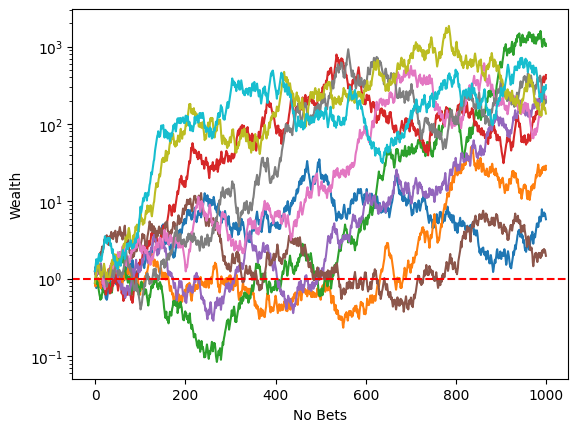

In [5]:
PnL = Kelly_Fraction_Simulation(n_sim  = 10, n_max_events = 1000)
for i in range(0,10):
  plt.plot(PnL[i])

plt.axhline(1, color='r', linestyle='--')
plt.yscale('log')
plt.xlabel('No Bets')
plt.ylabel('Wealth')

A large-scale simulation of potential betting-portfolio paths can be used to estimate expected returns, median outcomes, and confidence intervals. One commonly misunderstood property of the Kelly Criterion in the sports betting community concerns what it actually maximizes. A large number of people still expect the return value to be much larger than the one observed while they are suprised finding out the variability of their wealth getting reduced exttremely after a few bets due to a bad run.

The average return generated by Kelly staking can be extremely skewed. A small number of paths may compound to exceptionally high values, pulling the mean return upward to levels that are not representative of the typical bettor’s experience. By contrast, the median return under Kelly staking is much lower. This indicates that a few very rare and highly favorable paths create an unrealistic impression of the expected outcome.

For this reason, the median return is often a more representative metric when evaluating Kelly fraction staking, since it reflects the 50th-percentile outcome: half of the simulated paths finish above it and half finish below it.

As shown below, after 1,000 bets, the average return under full Kelly lies outside the upper 97.5% confidence interval of the median return. This means that the largest 2.5% of PnL paths contribute more to the mean than the remaining 97.5% of paths with lower outcomes.

By comparison, the same metrics are plotted for half-Kelly staking. In this case, the gap between the median and the average return after 1,000 bets is much smaller. Importantly, the median return is only around one order of magnitude lower than under full Kelly, while the average return is reduced by approximately three orders of magnitude. This suggests that half-Kelly staking greatly reduces the influence of extreme outlier paths while preserving much of the typical long-run growth.

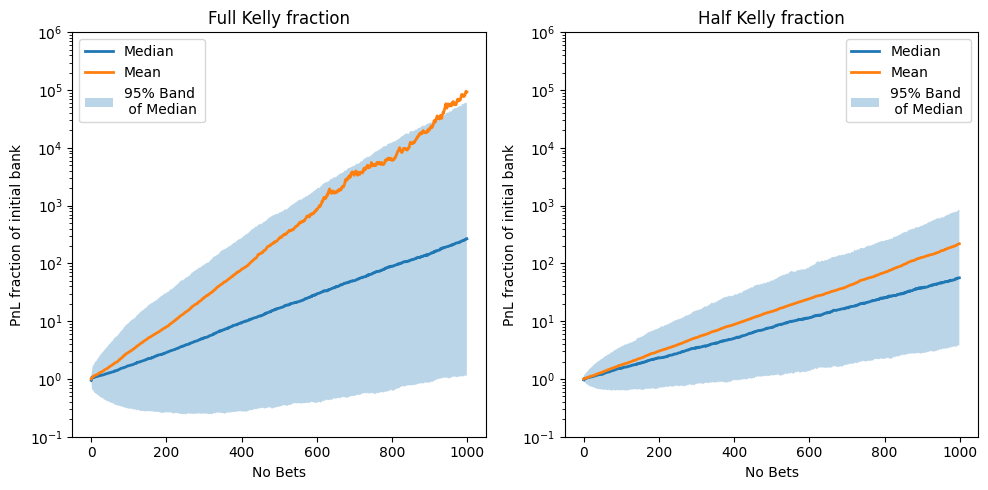

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

PnL_full_Kelly = Kelly_Fraction_Simulation(n_sim  = 10000, n_max_events = 1000,average_edge = 0.05)
Kelly_median = np.median(PnL_full_Kelly, axis=0)
Kelly_mean = np.mean(PnL_full_Kelly, axis=0)
p05 = np.percentile(PnL_full_Kelly, 5, axis=0)
p95 = np.percentile(PnL_full_Kelly, 95, axis=0)

axes[0].plot(Kelly_median, lw=2, label="Median")
axes[0].plot(Kelly_mean, lw=2, label="Mean")
axes[0].fill_between(range(PnL_full_Kelly.shape[1]), p05, p95, alpha=0.3, label = '95% Band \n of Median')
axes[0].set_xlabel('No Bets')
axes[0].set_ylabel('PnL fraction of initial bank')
axes[0].set_title('Full Kelly fraction')
axes[0].set_ylim(1e-1,1e6)
axes[0].set_yscale("log")
axes[0].legend()

PnL_half_Kelly = Kelly_Fraction_Simulation(n_sim  = 2000, n_max_events = 1000, kelly_fraction = 0.5,average_edge = 0.05)
half_Kelly_median = np.median(PnL_half_Kelly, axis=0)
half_Kelly_mean = np.mean(PnL_half_Kelly, axis=0)
p05 = np.percentile(PnL_half_Kelly, 5, axis=0)
p95 = np.percentile(PnL_half_Kelly, 95, axis=0)

axes[1].plot(half_Kelly_median, lw=2, label="Median")
axes[1].plot(half_Kelly_mean, lw=2, label="Mean")
axes[1].fill_between(range(PnL_half_Kelly.shape[1]), p05, p95, alpha=0.3, label = '95% Band \n of Median')

axes[1].set_xlabel('No Bets')
axes[1].set_ylabel('PnL fraction of initial bank')
axes[1].set_title('Half Kelly fraction')
axes[1].set_ylim(1e-1,1e6)
axes[1].set_yscale("log")
axes[1].legend()

plt.tight_layout()

### Volatility Drag:

After seeing the above plots there is an important question, why is the mean and median difference so large? There are many ways to approach that but in my opinion the best way to given an intuitive explanation is by the stochastic process that explains the wealth growth.


The wealth can be written as a stochastic equation of geometric brownian motion with proportional drift since there is an edge on our betting at the wealth is expected to have a long term upwards trend and there is a random walk based on the randomness of results changing the wealth by $1-f$ or $1+ b \cdot f$ at each step. The equations is:

$$ dW_t = \mu W_t dt + \sigma W_t dB_t \\ $$
where t is each step in our case being number of bets, $W_t$ is the wealth after t steps, $\mu$ is the proportional average increase at each step t, $\sigma$ is the proportional standard deviation and $B_t$ is a standard Brownian motion $B_t \sim N(0,t) $. The Brownian motion is practically a standard normal distribution which is getting a larger variance as we move forward in time so it can be writen as $ B_t = \sqrt{t} \cdot Z, Z(0,1) $.

Using Ito's lemma the above stochastic equation can be writen as:

$$ dlogW_t =  (\mu - \frac{1}{2} \sigma^2 ) dt + \sigma dB_t $$

Integrating form 0 to a wanted step T:

$$ logW_T = logW_0 +  (\mu - \frac{1}{2} \sigma^2 ) \cdot T + \sigma B_T =>$$

$$ W_T = W_0 \cdot \exp ( (\mu - \frac{1}{2} \sigma^2 ) \cdot T + \sigma B_T) =>$$

$$ W_T = W_0 \cdot \exp ( (\mu - \frac{1}{2} \sigma^2 ) \cdot T + \sqrt{T} \cdot \sigma \cdot Z(0,1) ) \\ $$

In the final formula of wealth $ W_T $ there is a random walk term $\sqrt{T} \cdot \sigma \cdot Z(0,1)$ that explaines the observed randomness of the potential wealth paths but also a  drift term that increases the mean at each stage $\mu - \frac{1}{2} \sigma^2 $ which is smaller than the mean that was used at the start by half the variance of the process. Practically the form of the drift term means that the long term trend is dragged down to lower values, a phenomenon called volatility drag.

The volatility drag creates a gap between the arithmetic mean and the geometric mean of amount $- \frac{1}{2} \sigma^2 $ leading to a higher probability of ending to the lower values paths while the higher value paths although having low probabilities they end up in extremely high values driving the arithmetic mean higher. So the arithmetic mean can be a tricky metric for calculating your wealth growth in general and the median is a much more usefull metric for understanding the potential paths and evaluting strategies and outcomes in cases of stochastic nature.




The Kelly Criterion asymptotically maximizes the median of the wealth as N tends to infinity but it is not leading to the maximum median value for all N values. For large N, the median terminal wealth is approximately:

$$
\operatorname{Median}(W_N)
\approx
W_0 \exp\left(\sum g(f,b,p)\right) $$

$$
g(f,b,p) = p \log(1 + bf) + q \log(1 - f).
$$

Lets use the same values of f,b,p as in the Kelly Criterion simulation for calculating the sum of the log-growth of the wealth g and then the simulated median with the approximate solution can be compared. As it can be seen the values are very close with acceptable agreement.

In [7]:
n_max_events = 1000
probability_market = norm.rvs(loc=0.5, scale=0.1, size=n_max_events)
probability_market = np.clip(probability_market, 1e-3, 1-1e-3)
prices_net = 1 / probability_market - 1
probability_model = probability_market + norm.rvs(loc=0.05, scale=0.01, size=n_max_events)
probability_model = np.clip(probability_model, 1e-3, 1-1e-3)
f = (prices_net * probability_model - (1 - probability_model)) / prices_net
sum_g = np.sum(probability_model*np.log(f*prices_net+1)+(1-probability_model)*np.log(1-f))

print('Simulated median:',np.round(Kelly_median[-1]),', Aproximate Median value',np.round(np.exp(sum_g)))

Simulated median: 267.0 , Aproximate Median value 255.0


The approximate solution holds for the half Kelly as well:

In [8]:
f = (1/2)*(prices_net * probability_model - (1 - probability_model)) / prices_net
sum_g = np.sum(probability_model*np.log(f*prices_net+1)+(1-probability_model)*np.log(1-f))

print('Simulated median:',np.round(half_Kelly_median[-1]),', Aproximate Median value',np.round(np.exp(sum_g)))

Simulated median: 56.0 , Aproximate Median value 63.0


### Including Risk considerations in Kelly fraction:

An issue withe the Kelly fraction is that it doens't consider volatility at all so it is hard to evaluate your risk directly on an investment and the log-growth maximization has not component for minimizing the risk of an action.

The simplest way to evaluate risk for a Kelly fraction strategy is by defining a failure threshold of wealth that any wealth path that reachs it counts as a failure and calculating the failure probability for a variety of different Kelly fraction values. An issue with Kelly fraction approaches is that theoretically the bankroll never goes to zero since the bankroll can be infinitely divided in smaller and smaller fractions of it.

The threshold is arbitrary for such a simple case and it can varries for different models or risk appetite that a bettor or investor has. For example 1% to 5% of bankroll for models with small edge could be considered reasonable probabilities' range of failure since it would take a large number of steps or bets to even reach the initial bankroll again and accounting the time or extra costs needed for a model it might need a much larger return than the initial bankroll to be even profitable at all. Another scenario for defining the failure threshold is by having a new model that needes some set number of bets in order to evaluate its edge. So for example 100 bets would be needed to have a decent probability of it being profitable so this testing period would have much higher threshold of failure compared to the case before.

At the end the optimal Kelly fraction adjusted to the given risk prefferences is the maximum f values that lies below the failure threshold.

In [2]:
def failure_prob(simulations, cutoff=0.10):

  failed = np.zeros(simulations.shape[0], dtype=bool)
  for i in range(simulations.shape[0]):
    idx = np.where(simulations[i] < cutoff)[0]
    if len(idx) > 0:
        first_fail = idx[0]
        simulations[i, first_fail:] = 0
        failed[i] = True

  n_failed = failed.sum()
  failure_rate = n_failed / len(failed)

  return failure_rate

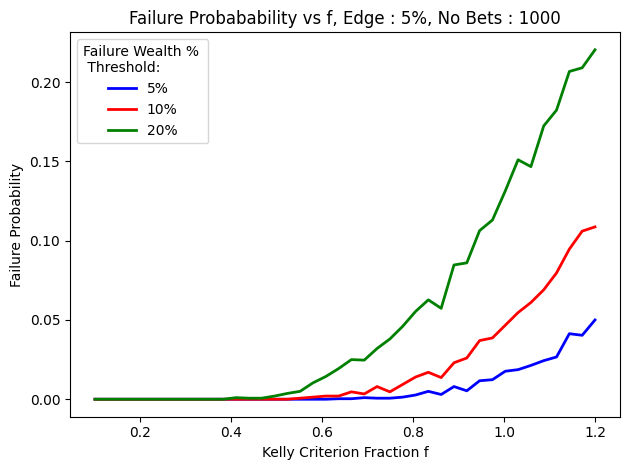

In [12]:
K_fractions_list = np.linspace(0.1,1.2,40)
failure_rate_5 = np.zeros(len(K_fractions_list))
failure_rate_10 = np.zeros(len(K_fractions_list))
failure_rate_20 = np.zeros(len(K_fractions_list))
for i in range(0,len(K_fractions_list)):
  PnL_sim = Kelly_Fraction_Simulation(n_sim  = 3000, n_max_events = 1000,kelly_fraction = K_fractions_list[i], average_edge = 0.025)
  failure_rate_5[i] = failure_prob(PnL_sim, cutoff=0.05)
  failure_rate_10[i] = failure_prob(PnL_sim, cutoff=0.10)
  failure_rate_20[i] = failure_prob(PnL_sim, cutoff=0.20)

plt.plot(K_fractions_list,failure_rate_5, color = 'b', lw =2, label = '5%')
plt.plot(K_fractions_list,failure_rate_10, color = 'r', lw =2, label = '10%')
plt.plot(K_fractions_list,failure_rate_20, color = 'g',lw = 2, label = '20%')

plt.legend(title = 'Failure Wealth % \n Threshold:')
plt.ylabel('Failure Probability')
plt.xlabel('Kelly Criterion Fraction f')
plt.title('Failure Probabability vs f, Edge : 5%, No Bets : 1000')

plt.tight_layout()

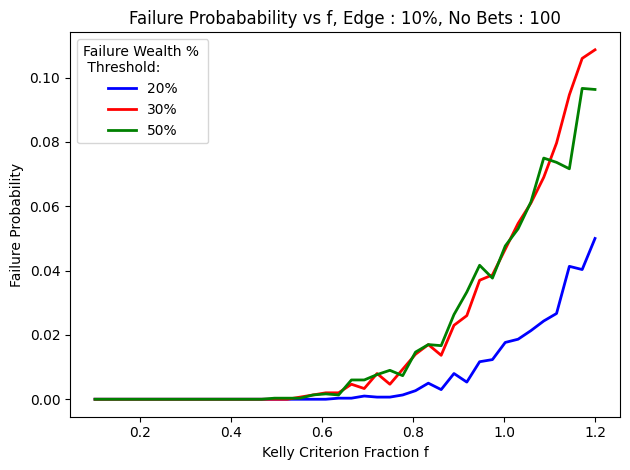

In [13]:
K_fractions_list = np.linspace(0.1,1.2,40)
failure_rate_20 = np.zeros(len(K_fractions_list))
failure_rate_30 = np.zeros(len(K_fractions_list))
failure_rate_50 = np.zeros(len(K_fractions_list))
for i in range(0,len(K_fractions_list)):
  PnL_sim = Kelly_Fraction_Simulation(n_sim  = 3000, n_max_events = 100,kelly_fraction = K_fractions_list[i], average_edge = 0.05)
  failure_rate_20[i] = failure_prob(PnL_sim, cutoff=0.20)
  failure_rate_30[i] = failure_prob(PnL_sim, cutoff=0.30)
  failure_rate_50[i] = failure_prob(PnL_sim, cutoff=0.50)

plt.plot(K_fractions_list,failure_rate_5, color = 'b', lw =2, label = '20%')
plt.plot(K_fractions_list,failure_rate_10, color = 'r', lw =2, label = '30%')
plt.plot(K_fractions_list,failure_rate_20, color = 'g',lw = 2, label = '50%')

plt.legend(title = 'Failure Wealth % \n Threshold:')
plt.ylabel('Failure Probability')
plt.xlabel('Kelly Criterion Fraction f')
plt.title('Failure Probabability vs f, Edge : 10%, No Bets : 100')

plt.tight_layout()

## Reactive Markets to liquidity:

### Creating a simple market toy model:

A proper approach that reflects any kind of market has to include an order book of an exchange but for this notebook a simplified version of a market will be used in the form of a Beta distribution. This is a closer approach to a bookie market where they can only accept bets on an event to happen or to not and based on the stakes and the prior bilief of the opening line the odds are updated for minimizing the book's risk.

A very simple way to model a 2-way market that evolves with stakes being added is the Beta distribution $ Beta(\alpha, \beta) $ with mean and standard deviation:

$$ \mu = \frac{\alpha}{\alpha + \beta}, \sigma = \frac{\alpha \cdot \beta}{(\alpha + \beta)^2 \cdot (\alpha+\beta+1)} $$

The market is practically the trading of the probability value of an event with the buy and sell value to be $ \mu \pm \sigma $ of the Beta distribution and to updating by changing the values of $\alpha$ and $\beta$. If a market participant wants to bet on the event traded to happen they add their stake to $\alpha$ and in the opposite case the stake is added to $\beta$. After each update of the market based on the new $\alpha, \beta$ the new probability is calculated by the updated $ \mu \pm \sigma $ .

For the case of an exchange the $\alpha$ and $\beta$ would be 1 and they would rapidly change by the stakes being added tending asympotically to the true probability by the mean of the Beta. The initial parameters $\alpha$ and $\beta$ practically for a bookie can be defined by the trust there is to the opening lines or the standard deviation of a market from its opening line to its closing value.

In [3]:
def beta_stats(a, b):
    mean = a / (a + b)
    variance = (a * b) / ((a + b)**2 * (a + b + 1))
    std = np.sqrt(variance)

    return mean, std

def market_update(liq_unit_for = 0,liq_unit_ag = 0,a_0 = 100, b_0 = 100):

  a = a_0 + liq_unit_for
  b = b_0 + liq_unit_ag

  prob = a/(a+b)
  dprob = prob - a_0/(a_0+b_0)

  return a, b, prob, dprob


Now let's assume a market where all the participants are well informed and fully reasonable meaning that they all know the true probability and event and when they see the opening lines they know which is line has value. The probability of the event can be well defined from the start without any additional information during the evolution of the market. The stakes on each time step are following a normal distribution with mean proportional to the edge or the probability diffference between the actual probability and the true probability value:

$$ stake_{i} = N(P_{actual} - P_{market_i}, 0.02)  $$

The stake value above is assumed to be the sum f a large number of bets at each time step and thus the randmness but also the possibility of negative stakes translated to bets on the option on the market not happening or losing.

The opening line is staring at the value of 50% with the initial values being $\alpha_0, \beta_0$ both 10 and the actual probability being 35%.

In [4]:

sim_n = 2000
prob_list = np.zeros(sim_n)
a = 10
b = 10
m_0, sigma_0 = beta_stats(a, b)

act = 0.35
prob = m_0

for i in range(0,sim_n):
  stake = norm.rvs(loc = act - prob, scale=0.02, size=1)[0]
  if stake > 0:
    a, b, prob, dprob = market_update(liq_unit_for = stake,liq_unit_ag = 0,a_0 = a, b_0 = b)
  else:
    a, b, prob, dprob = market_update(liq_unit_for = 0,liq_unit_ag = -stake,a_0 = a, b_0 = b)
  prob_list[i] = prob



As it is shown below the toy model of the market converges to the true probability very fast succesfully with the noise being visible as well:

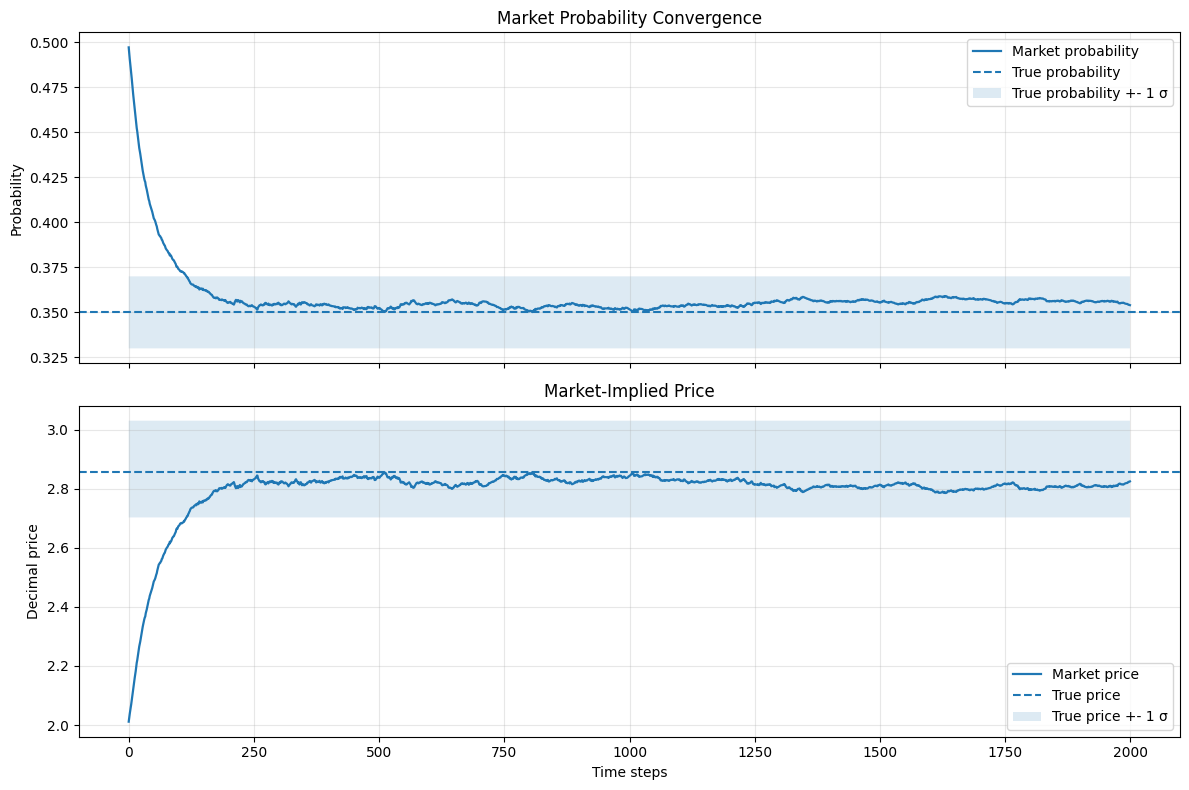

In [5]:
time = np.arange(sim_n)

true_prob = act
upper_prob = act + 0.02
lower_prob = act - 0.02

market_price = 1 / prob_list
true_price = 1 / true_prob
upper_price = 1 / lower_prob
lower_price = 1 / upper_prob

fig, axes = plt.subplots(2, 1,figsize=(12, 8),sharex=True)

axes[0].plot(time,prob_list,label="Market probability",linewidth=1.6)

axes[0].axhline(true_prob,linestyle="--",linewidth=1.5,label="True probability")

axes[0].fill_between(time,lower_prob,upper_prob,alpha=0.15,label="True probability +- 1 σ")

axes[0].set_ylabel("Probability")
axes[0].set_title("Market Probability Convergence")
#axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="best")

axes[1].plot(time,market_price,label="Market price",linewidth=1.6)

axes[1].axhline(true_price,linestyle="--",linewidth=1.5,label="True price")

axes[1].fill_between(time,lower_price,upper_price,alpha=0.15,label="True price +- 1 σ")

axes[1].set_xlabel("Time steps")
axes[1].set_ylabel("Decimal price")
axes[1].set_title("Market-Implied Price")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()

### Adding type of traders information in the market model:

The toy model can become more accurate by adding an additional level of compexity that is found in betting markets. The two main categories of market participants or traders are the sharps like the traders in the previous example that are trying to extract profit by betting on markets with wrong values and the dummy traders that just gamble with very low sensitivity to potential edges who just randomly bet on a market.

The sharp traders bet to markets on the side that has value with stakes following a normal distribution with its mean being his edge:
$$ stake_{i} = N(P_{actual} - P_{market_i}, 0.02)  \\ $$


The dummy traders bet to markets almost randomly with a 10 times less sensitivity to edge and with much larger variance than the sharp traders. Another important pat of the dummy traders betting is that they bet more and more as the time of an event is approaching with maximum at scale minutes before a game start while they bet almost nothing very early on. For this reason a time faunction f is used to capture this phenomenon which is increasing with time passing $t_s$ at each s step. The formula of the dummy staking is:

$$ stake_{i} = f(t_s) \cdot N(\frac{P_{actual} - P_{market_i}}{10}, 0.20) \\
f(t_s) = \frac{\sqrt{t_s}}{100} $$

In [6]:
sim_n = 2000
prob_list = np.zeros(sim_n)
liability_a = np.zeros(sim_n)
liability_b = np.zeros(sim_n)
stake_a = np.zeros(sim_n)
stake_b = np.zeros(sim_n)
e_value_sharp = np.zeros(sim_n)
a_liab = 0
b_liab = 0
a = 10
b = 10
m_0, sigma_0 = beta_stats(a, b)

act = 0.35
prob = m_0

for i in range(0,sim_n):
  stake_sharp = norm.rvs(loc = act - prob, scale=0.02, size=1)[0]
  stake = (np.sqrt(i)/100) * norm.rvs(loc = (act - prob)/10, scale=0.1, size=1)[0]
  stake += stake_sharp
  if stake > 0:
    a_liab += stake*(1/prob-1)
    stake_a[i] = stake
    stake_b[i] = 0

    a, b, prob, dprob = market_update(liq_unit_for = stake,liq_unit_ag = 0,a_0 = a, b_0 = b)
  else:
    b_liab += -stake*(1/(1-prob)-1)
    stake_a[i] = 0
    stake_b[i] = -stake

    a, b, prob, dprob = market_update(liq_unit_for = 0,liq_unit_ag = -stake,a_0 = a, b_0 = b)

  if stake_sharp > 0:
    e_value_sharp[i] = np.abs(stake_sharp)*((1/prob-1)-(1/act-1))
  else:
    e_value_sharp[i] = np.abs(stake_sharp)*((1/(1-prob)-1)-(1/(1-act)-1))

  prob_list[i] = prob
  liability_a[i] = a_liab
  liability_b[i] = b_liab

A first question is what is the profit of the sharp traders in this market with no margin. The EV of the sharp trader is calculated as:

$$ EV_{Sharp} = \sum stake_{i} \cdot (Price_{True} - Price_{market}), Price_{True} > Price_{market} $$

 As it can be shown below all the value extracted comes from the early stages (until 100th step) of the market since the edge is large and so the sharp's stakes while after the market being stabilized the betting practically stops and there is only some noise.

Text(0, 0.5, 'Sharp Trader EV Cumulative')

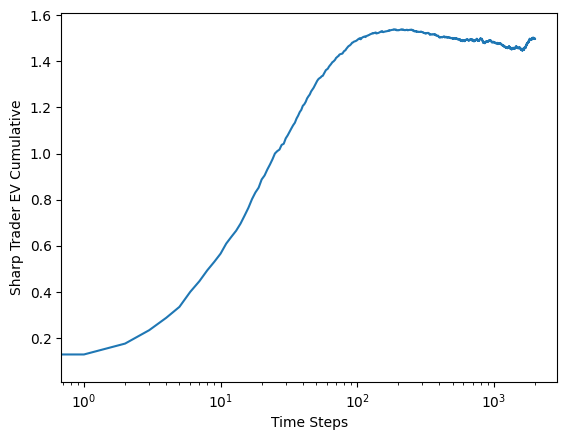

In [7]:
plt.plot(np.cumsum(e_value_sharp))
plt.xscale('log')
plt.xlabel('Time Steps')
plt.ylabel('Sharp Trader EV Cumulative')

A key metric from the perspective of a bookie or any sort of liquidity provider in this market is the expected value of the total book, meaning the profit or loses for the provider. Knowing that there is no margin and the opening line was way off from the actual line obviously the total EV is expected to be negative for this case. There two scenarios for this two way market, event happening with probability p leading to paying $Liab_{a}$ and earning $stake_{b}$ and the event not happening with probability of (1-p) leading to paying $Liab_{b}$ and earning $stake_{a}$:

$$ EV_{book} = p \cdot (Stake_{b}-Liab_{a}) + (1-p) \cdot (Stake_{a}-Liab_{b}) $$

The overall market is ending up losing only 1.57% which is relatively low regarding the initial probability offset. The total stake units lost are around 1 unit, while the total EV of the sharp trader was 1.4 units meaing that after the sharp traders correcting the markets and collecting their EV the market performed optimally as expected.

In [8]:
stake_a_cum = np.cumsum(stake_a)
stake_b_cum = np.cumsum(stake_b)
total_stake = stake_a_cum + stake_b_cum
book_ev = (act * (-liability_a + stake_b_cum)+ (1 - act) * (-liability_b+ stake_a_cum))/total_stake

print('Total EV:',np.round(book_ev[-1]*total_stake[-1],2),'units or',np.round(100 * book_ev[-1],2),'%, Total Stakes:',np.round(total_stake[-1]),'units')

Total EV: -1.06 units or -1.61 %, Total Stakes: 66.0 units


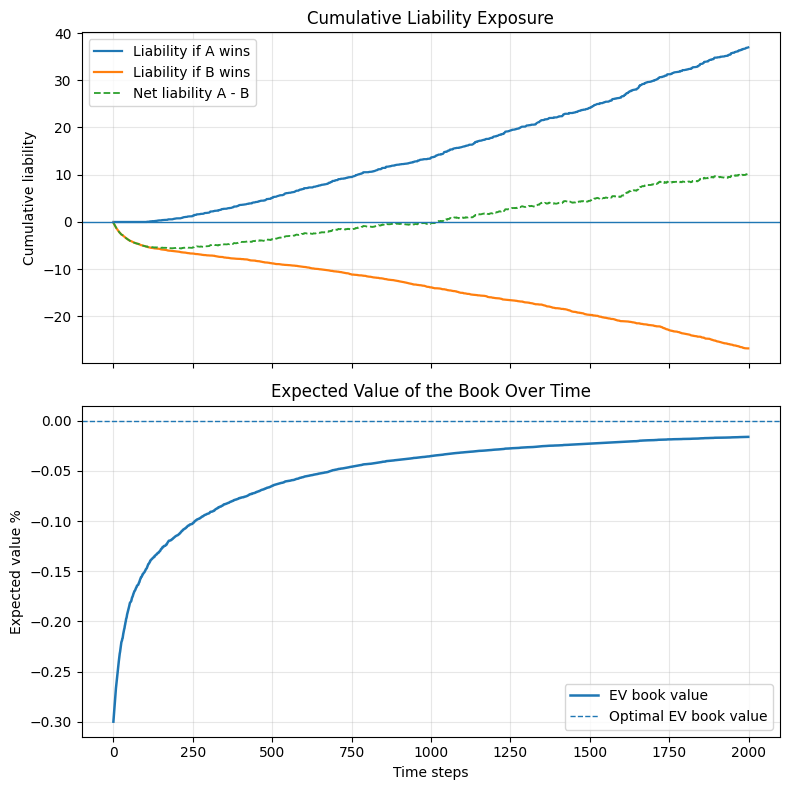

In [9]:
time = np.arange(sim_n)

fig, axes = plt.subplots(2, 1,figsize=(8, 8),sharex=True)

axes[0].plot(time,liability_a,label="Liability if A wins",linewidth=1.6)
axes[0].plot(time,-liability_b,label="Liability if B wins",linewidth=1.6)
axes[0].plot(time,liability_a - liability_b,label="Net liability A - B",linewidth=1.3,linestyle="--")

axes[0].axhline(0, linewidth=1)
axes[0].set_ylabel("Cumulative liability")
axes[0].set_title("Cumulative Liability Exposure")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="best")

axes[1].plot(time,book_ev,label="EV book value",linewidth=1.8)

axes[1].axhline(0,linewidth=1,linestyle="--",label="Optimal EV book value")
axes[1].set_xlabel("Time steps")
axes[1].set_ylabel("Expected value %")
axes[1].set_title("Expected Value of the Book Over Time")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()

The same market simulation is performed with the addition of margin to the offered prices. Both dummy and sharp traders are acting with the same reasoning as before with the difference being that the sharp traders compete only if one of the 2-way offered prices have value (being higher than the actual price value). The 2-way market with margin m has a range of values in which arbitrage is not possible:

$$ p_{marginated} \in [p,p+m] , q_{marginated} \in [q,q+m]$$
where $q = 1-p$.


But there is a problem in such markets that have as high margins as sportsbook. The sharp traders are going to move the line towards to the true probability but they will stop when they 'll reach the probability adjusted for margin so there will be a gap between the true probability and the market probability equal to $p+margin$ where p is the true probability. From that point on the sharp traders are just going to correct any small deviations from the marginated probability while the other side of the market would stabilize to its fair value. This can be shown below for a simulated market with 5% margin:

In [10]:
sim_n = 2000
margin = 0.05

prob_list = np.zeros(sim_n)
liability_a = np.zeros(sim_n)
liability_b = np.zeros(sim_n)
stake_a = np.zeros(sim_n)
stake_b = np.zeros(sim_n)
price_a_list = np.zeros(sim_n)
price_b_list = np.zeros(sim_n)

a_liab = 0
b_liab = 0

a = 10
b = 10

m_0, sigma_0 = beta_stats(a, b)

act = 0.35
true_price_a = 1 / act
true_price_b = 1 / (1 - act)
prob = m_0

for i in range(sim_n):

  prob_before = prob
  price_a = 1 / (prob_before * (1 + margin))
  price_b = 1 / ((1 - prob_before) * (1 + margin))

  if (price_a - true_price_a > 0) or (price_b - true_price_b > 0):

    stake_sharp = norm.rvs(loc=act - prob_before,scale=0.02,size=1)[0]
  else:
    stake_sharp = 0

  stake = (np.sqrt(i) / 100) * norm.rvs(loc=(act - prob_before) / 10,scale=0.2,size=1)[0]

  stake += stake_sharp

  if stake > 0:
    a_liab += stake * (price_a - 1)
    stake_a[i] = stake
    stake_b[i] = 0

    a, b, prob, dprob = market_update(liq_unit_for=stake,liq_unit_ag=0,a_0=a,b_0=b)

  else:
    b_liab += -stake * (price_b - 1)
    stake_a[i] = 0
    stake_b[i] = -stake

    a, b, prob, dprob = market_update(liq_unit_for=0,liq_unit_ag=-stake,a_0=a,b_0=b)

  prob_list[i] = prob
  liability_a[i] = a_liab
  liability_b[i] = b_liab
  price_a_list[i] = price_a
  price_b_list[i] = price_b

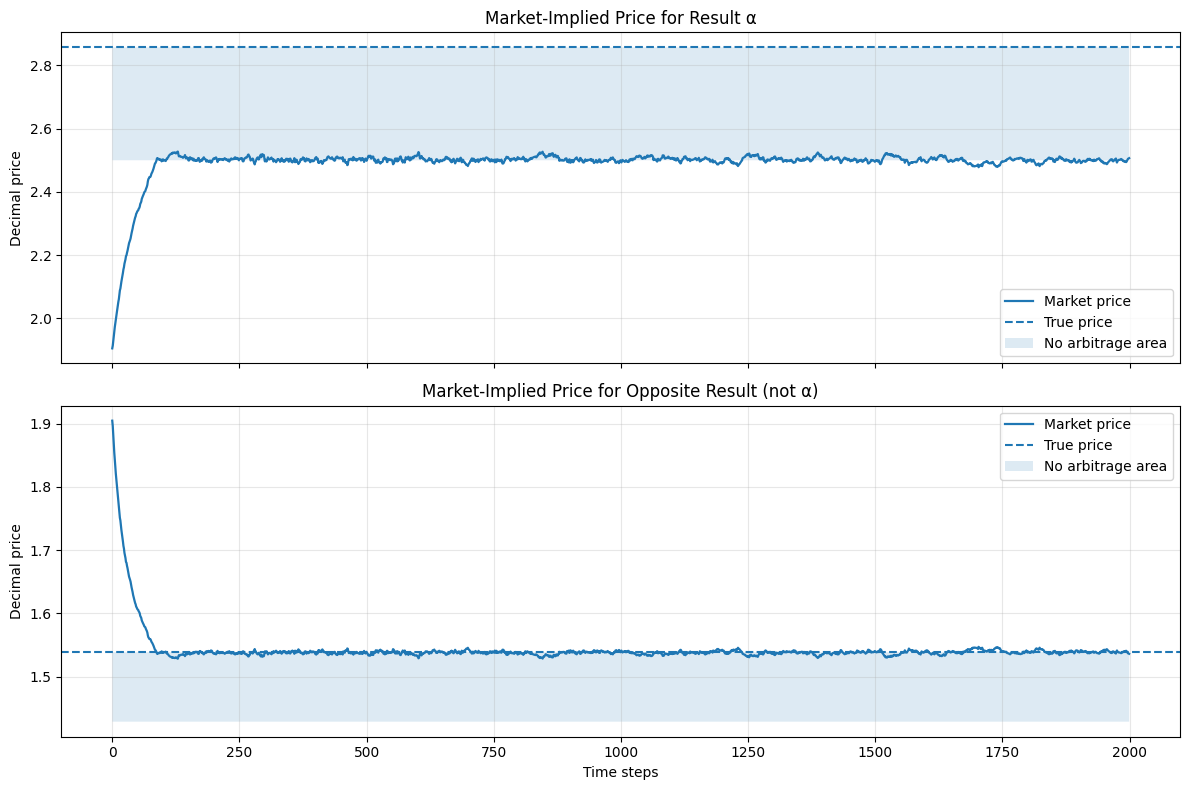

In [11]:
time = np.arange(len(prob_list))
fig, axes = plt.subplots(2, 1,figsize=(12, 8),sharex=True)

axes[0].plot(time,price_a_list,label="Market price",linewidth=1.6)

axes[0].axhline(true_price_a,linestyle="--",linewidth=1.5,label="True price")
axes[0].fill_between(time,1 / (act + margin),true_price_a,alpha=0.15,label="No arbitrage area")

axes[0].set_ylabel("Decimal price")
axes[0].set_title("Market-Implied Price for Result α")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="best")


axes[1].plot(time,price_b_list,label="Market price",linewidth=1.6)

axes[1].axhline(true_price_b,linestyle="--",linewidth=1.5,label="True price")
axes[1].fill_between(time,1 / (1 - act + margin),true_price_b,alpha=0.15,label="No arbitrage area")

axes[1].set_xlabel("Time steps")
axes[1].set_ylabel("Decimal price")
axes[1].set_title("Market-Implied Price for Opposite Result (not α)")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="best")

plt.tight_layout()

The correction for the above bizarre prices' result can be corrected by assuming that the actual probability is not perfectly defined but there is some noise around it at each step. With this correction more radomness is added to the model which is closer to the actual betting markets but the sharp traders are not always winning as before since they do not know the true probability with zero error.

The the prices after the price correction period fluctuate within the no arbitrage area with margin applied to both sides with is the picture of a "healthy" market. The EV of the Book is asymptotically tending to the 5% expectation due to the margin so the simulation works as expected and captures a large part of real life betting markets.

In [12]:
sim_n = 2000
margin = 0.05

prob_list = np.zeros(sim_n)
liability_a = np.zeros(sim_n)
liability_b = np.zeros(sim_n)
stake_a = np.zeros(sim_n)
stake_b = np.zeros(sim_n)
price_a_list = np.zeros(sim_n)
price_b_list = np.zeros(sim_n)

a_liab = 0
b_liab = 0

a = 10
b = 10

m_0, sigma_0 = beta_stats(a, b)

act_0 = 0.35
prob = m_0

for i in range(sim_n):

  act = act_0 + norm.rvs(0,0.05,1)[0]

  true_price_a = 1 / act
  true_price_b = 1 / (1 - act)

  prob_before = prob
  price_a = 1 / (prob_before * (1 + margin))
  price_b = 1 / ((1 - prob_before) * (1 + margin))

  if (price_a - true_price_a > 0) or (price_b - true_price_b > 0):

    stake_sharp = norm.rvs(loc=act - prob_before,scale=0.02,size=1)[0]
  else:
    stake_sharp = 0

  stake = (np.sqrt(i) / 100) * norm.rvs(loc=(act - prob_before) / 5,scale=0.2,size=1)[0]

  stake += stake_sharp

  if stake > 0:
    a_liab += stake * (price_a - 1)
    stake_a[i] = stake
    stake_b[i] = 0

    a, b, prob, dprob = market_update(liq_unit_for=stake,liq_unit_ag=0,a_0=a,b_0=b)

  else:
    b_liab += -stake * (price_b - 1)
    stake_a[i] = 0
    stake_b[i] = -stake

    a, b, prob, dprob = market_update(liq_unit_for=0,liq_unit_ag=-stake,a_0=a,b_0=b)

  prob_list[i] = prob
  liability_a[i] = a_liab
  liability_b[i] = b_liab
  price_a_list[i] = price_a
  price_b_list[i] = price_b

In [13]:
stake_a_cum = np.cumsum(stake_a)
stake_b_cum = np.cumsum(stake_b)

pnl_if_a_wins = stake_b_cum - liability_a
pnl_if_b_wins = stake_a_cum - liability_b

book_ev = (prob_list * pnl_if_a_wins+ (1 - prob_list) * pnl_if_b_wins)/(stake_a_cum + stake_b_cum)

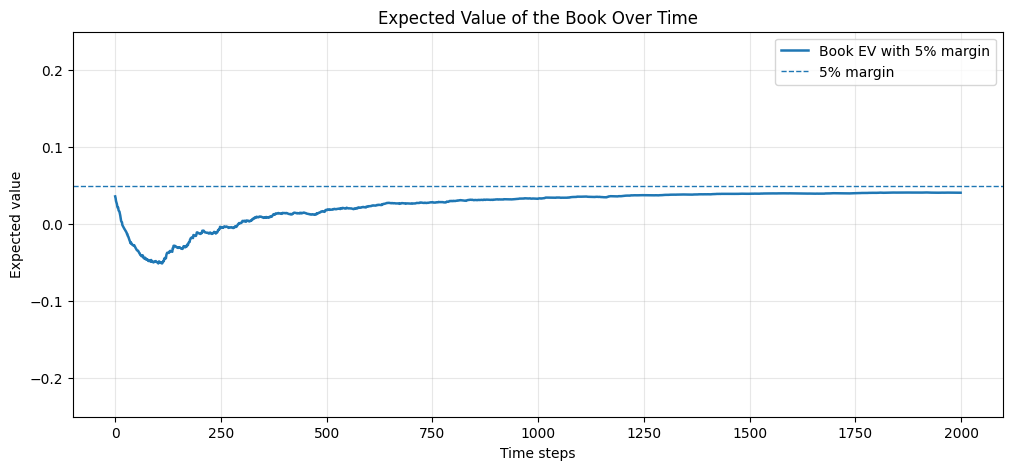

In [14]:
plt.figure(figsize=(12, 5))

plt.plot(book_ev, label="Book EV with 5% margin", linewidth=1.8)
plt.axhline(margin, linestyle="--", linewidth=1, label="5% margin")

plt.xlabel("Time steps")
plt.ylabel("Expected value")
plt.title("Expected Value of the Book Over Time")
plt.ylim(-0.25,0.25)
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

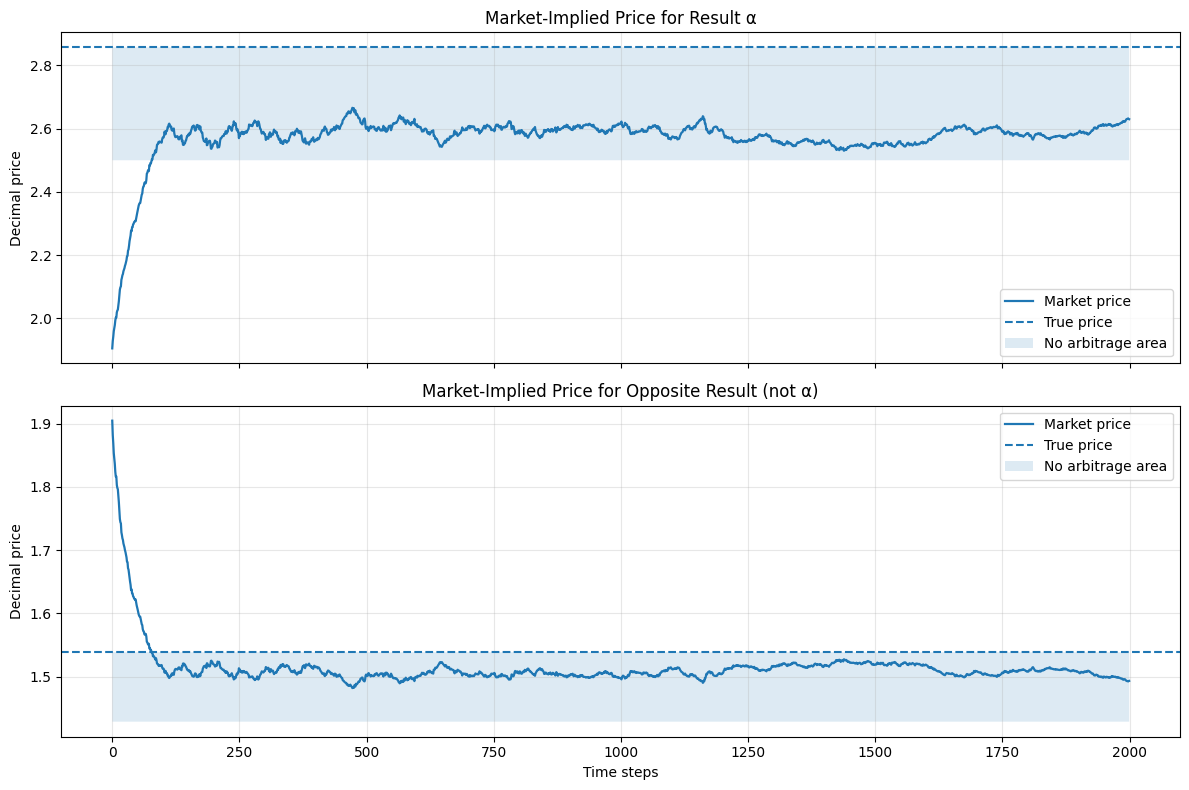

In [15]:
time = np.arange(len(prob_list))
fig, axes = plt.subplots(2, 1,figsize=(12, 8),sharex=True)

axes[0].plot(time,price_a_list,label="Market price",linewidth=1.6)

axes[0].axhline(1/act_0,linestyle="--",linewidth=1.5,label="True price")
axes[0].fill_between(time,1 / (act_0 + margin),1/act_0,alpha=0.15,label="No arbitrage area")

axes[0].set_ylabel("Decimal price")
axes[0].set_title("Market-Implied Price for Result α")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="best")


axes[1].plot(time,price_b_list,label="Market price",linewidth=1.6)

axes[1].axhline(1/(1-act_0),linestyle="--",linewidth=1.5,label="True price")
axes[1].fill_between(time,1 / (1 - act_0 + margin),1/(1-act_0),alpha=0.15,label="No arbitrage area")

axes[1].set_xlabel("Time steps")
axes[1].set_ylabel("Decimal price")
axes[1].set_title("Market-Implied Price for Opposite Result (not α)")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="best")

plt.tight_layout()

### Market Manipulation:

Assuming that a betting market works according to the model defined above a trader could manipulate the odds if he knew the exact $\alpha,\beta$ at the wanted momment. A potential problem with market manipulation is the liquidity of the sharp traders since they can correct the market very fast and making manipulation for long times impossible. But in low liquidity markets which usually have very high margins as well the lack of sharp money is observed regularly.

For this reason we assume the simple case of no sharp money involved and the market follows the same Beta distribution $Beta(\alpha, \beta)$ as before with the probability estimation being its mean value:

$$\mu = \frac{\alpha}{\alpha+\beta}  \\ $$

 The option a trader has is to update the $\alpha,\beta$ at each bet, for this case the trader has only the option to change the $\alpha$ value to $\alpha'$ and the probability value from $\mu$ to $\mu'$so for each step:

 $$ \alpha' = \alpha + \Delta \alpha, \beta' = \beta \\
 \mu' = \frac{\alpha + \Delta \alpha}{ \beta + \alpha + \Delta \alpha}$$

A new variable S is defined as:

$$S = \alpha + \beta, \\
\alpha = S \cdot \mu, \beta = S \cdot (1- \mu) \\
\mu' = \frac{\mu \cdot \Delta \alpha - \Delta \alpha}{S + \Delta \alpha}$$

Solving to S with get:

$$ S = \frac{\Delta \alpha \cdot (1- \mu')}{\mu' - \mu} $$

Not given the $\alpha, \beta $ euations expressed to S we can calculate both parameters given the $\Delta \alpha$ and the new probability mean $\mu'$ following:

$$ a = \mu \cdot \frac{\Delta \alpha \cdot (1-\mu')}{\mu'-\mu} \\
b = (1-\mu) \frac{\Delta \alpha \cdot (1-\mu')}{\mu'-\mu}
$$

Similarly for the case fo changing $\beta $ instead of $\alpha$ the parameters are estimated as:
$$ a = \mu \frac{\mu' \cdot \Delta \beta }{\mu - \mu'} $$

$$ b = (1-\mu) \cdot \frac{\mu' \Delta \beta }{\mu-\mu'} $$

In [16]:
def beta_params_estim(d_a_case, d_ab, mu, mu_new):

  if d_a_case == True:
    a = mu * (d_ab * (1-mu_new)) / (mu_new - mu)
    b = (1 - mu) * (d_ab * (1-mu_new)) / (mu_new - mu)
  else:
    a = mu * (mu_new * d_ab) / (mu - mu_new)
    b = (1 - mu) * (mu_new * d_ab) / (mu - mu_new)

  return a, b

The same market simulation is done below again without any sharp traders but with a manipulator that bets every 100 tme steps and collects the probability differences in order to estimate the Beta distribution's parameters. In this case due to the lack of the sharp traders the line is not correct (there is very small edge sensitivity for the dummy traders) so the probability just follows a random walk around the initial price (with a tiny drift).

In [38]:
sim_n = 2000
prob_list = np.zeros(sim_n)
a = 10
b = 10
m_0, sigma_0 = beta_stats(a, b)
alphas = []
betas = []
m_old_list = []
m_new_list = []

act = 0.35
prob = m_0

for i in range(0,sim_n):
  if i % 100 == 0:
    stake_manip = 1
    m_old_list.append(prob)
    alphas.append(a)
    betas.append(b)
  else:
    stake_manip = 0

  stake = (np.sqrt(i)/100) * norm.rvs(loc = (act - prob)/10, scale=0.2, size=1)[0]
  stake += stake_manip
  if stake > 0:
    a, b, prob, dprob = market_update(liq_unit_for = stake,liq_unit_ag = 0,a_0 = a, b_0 = b)
  else:
    a, b, prob, dprob = market_update(liq_unit_for = 0,liq_unit_ag = -stake,a_0 = a, b_0 = b)

  if i % 100 == 0:
    m_new_list.append(prob)

  prob_list[i] = prob

In [39]:
a_estim = np.zeros(len(m_new_list))
b_estim = np.zeros(len(m_new_list))

for i in range(0,len(m_new_list)):
  a_estim[i], b_estim[i] = beta_params_estim(d_a_case = True, d_ab = 1, mu = m_old_list[i], mu_new = m_new_list[i])

At a first glance the parameters are estimated with great accuracy especially at early steps when the liquidity is low. For laters steps close to 2000 the liquidity is large at every step so there is additional error to the parameters' estimations but this could be even fixed with an time adjusted stake for the manipulator since it this version he is staking the same amount from start to end.

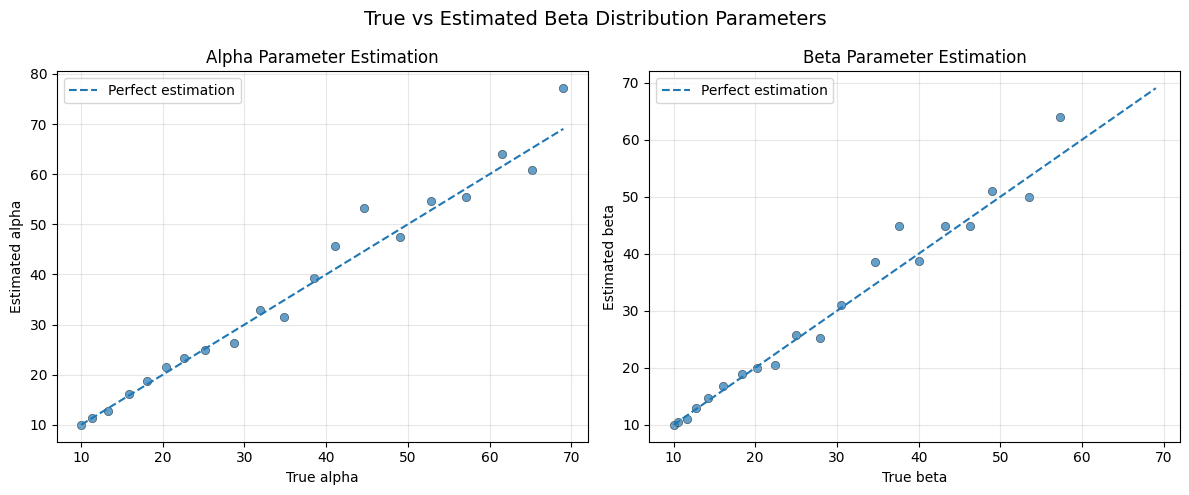

In [40]:
fig, axes = plt.subplots(1, 2,figsize=(12, 5))
identity_line = np.linspace(min(alphas), max(alphas), 200)

axes[0].scatter(alphas,a_estim,alpha=0.7,edgecolor="black",linewidth=0.4)
axes[0].plot(identity_line,identity_line,linestyle="--",linewidth=1.5,label="Perfect estimation")

axes[0].set_title("Alpha Parameter Estimation")
axes[0].set_xlabel("True alpha")
axes[0].set_ylabel("Estimated alpha")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="best")

axes[1].scatter(betas,b_estim,alpha=0.7,edgecolor="black",linewidth=0.4)
axes[1].plot(identity_line,identity_line,linestyle="--",linewidth=1.5,label="Perfect estimation")

axes[1].set_title("Beta Parameter Estimation")
axes[1].set_xlabel("True beta")
axes[1].set_ylabel("Estimated beta")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="best")

plt.suptitle("True vs Estimated Beta Distribution Parameters", fontsize=14)
plt.tight_layout()

Next step after having parameters estimations for a range of time steps a function for the time dependance of the parameters cas be fitted in order to estimate the alpha at specific momments when the manipulator wants to act. As it can be seen below the $\alpha,\alpha + \beta $ can be fitted greatly with a simple polynomial of second degree.

In practice the same process would need much more data from paramaters estimations even conditional to specific teams and odds ranges since these parameters are having a large effect at the dummy traders stake sizes.

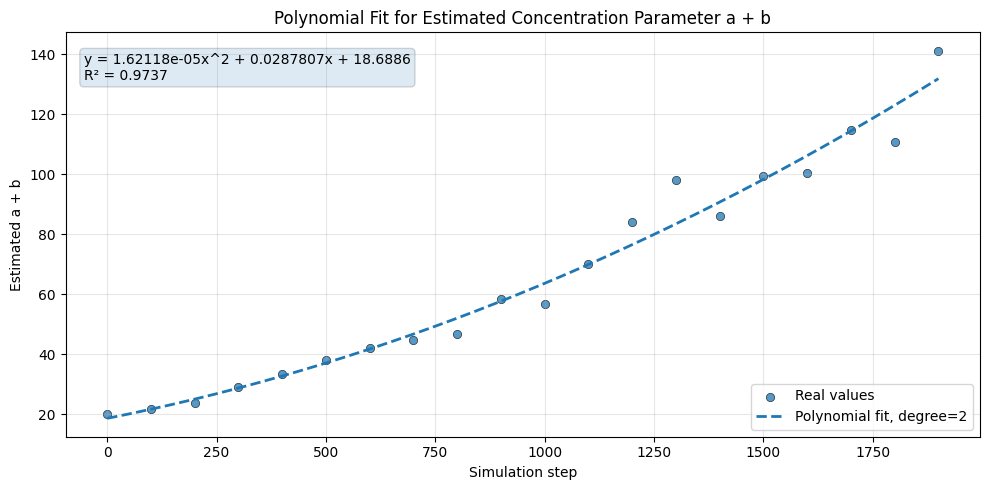

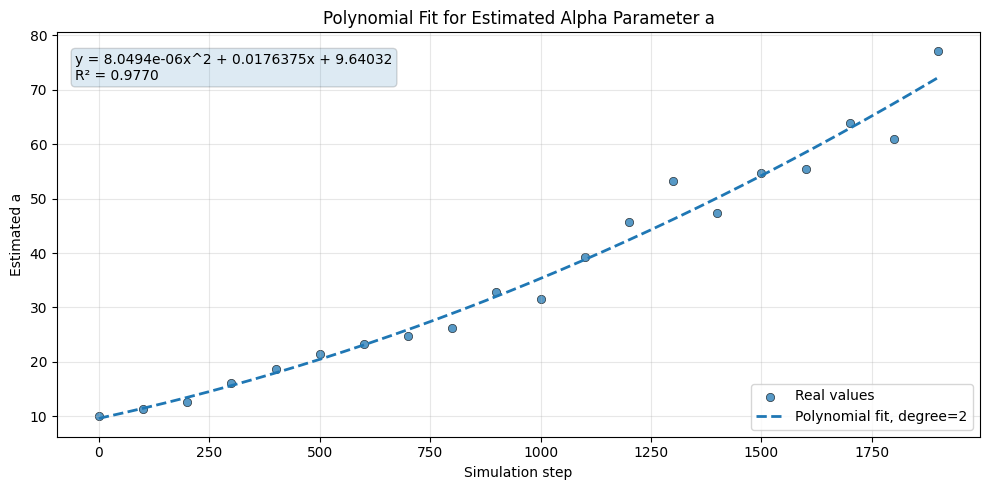

In [41]:
x = np.arange(0, 100 * len(a_estim), 100)
poly_degree = 2

def fit_polynomial_and_plot(x, y, title, xlabel, ylabel, poly_degree=2):
    coeffs = np.polyfit(x, y, poly_degree)
    poly = np.poly1d(coeffs)

    x_fit = np.linspace(x.min(), x.max(), 500)
    y_fit = poly(x_fit)

    y_pred = poly(x)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot

    equation_terms = []
    degree = len(coeffs) - 1

    for i, c in enumerate(coeffs):
        power = degree - i
        if power > 1:
            equation_terms.append(f"{c:.6g}x^{power}")
        elif power == 1:
            equation_terms.append(f"{c:.6g}x")
        else:
            equation_terms.append(f"{c:.6g}")

    equation = " + ".join(equation_terms).replace("+ -", "- ")


    plt.figure(figsize=(10, 5))
    plt.scatter(x,y,label="Real values",alpha=0.75,edgecolor="black",linewidth=0.5)
    plt.plot(x_fit,y_fit,linestyle="--",linewidth=2,label=f"Polynomial fit, degree={poly_degree}")

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.text(0.02,0.95,f"y = {equation}\nR² = {r2:.4f}",transform=plt.gca().transAxes,verticalalignment="top",bbox=dict(boxstyle="round", alpha=0.15))
    plt.tight_layout()

    return coeffs, r2


coeffs_total, r2_total = fit_polynomial_and_plot(x=x,y=a_estim + b_estim,title="Polynomial Fit for Estimated Concentration Parameter a + b",xlabel="Simulation step",
    ylabel="Estimated a + b",poly_degree=poly_degree)

coeffs_a, r2_a = fit_polynomial_and_plot(x=x,y=a_estim,title="Polynomial Fit for Estimated Alpha Parameter a",xlabel="Simulation step",ylabel="Estimated a",
    poly_degree=poly_degree)

Now in this case the manipulator after estimating the $\alpha,\beta$ parameters through betting one unit, in the next step he stakes the appropriate amount for moving the line to the wanted wrong price. We can enters the market at any time step within [500,1000] while he dummy traders are expected to correct the line much slower than the previous cases with sharp traders due to thei low sensitivity.

For making the problem of the manipulator harder the opening line is closer to the actual probability value.

In [45]:
sim_n = 2000
prob_list = np.zeros(sim_n)
a = 5
b = 15
m_0, sigma_0 = beta_stats(a, b)
alphas = []
betas = []
m_old_list = []
m_new_list = []

act = 0.35
manip_prob = 0.6
prob = m_0

manipulator_action_step = np.random.randint(500, 1000)

for i in range(0,sim_n):
  if i == manipulator_action_step:
    stake_manip = 1
    mu_old = prob
  elif i == manipulator_action_step+1:
    if manip_prob > prob:
      stake_manip = (a + b) * (manip_prob - act)/(1 - manip_prob)
    else:
      stake_manip = -(a + b) * (act - manip_prob)/manip_prob
  else:
    stake_manip = 0

  stake = (np.sqrt(i)/100) * norm.rvs(loc = (act - prob)/30, scale=0.2, size=1)[0]
  stake += stake_manip
  if stake > 0:
    a, b, prob, dprob = market_update(liq_unit_for = stake,liq_unit_ag = 0,a_0 = a, b_0 = b)
  else:
    a, b, prob, dprob = market_update(liq_unit_for = 0,liq_unit_ag = -stake,a_0 = a, b_0 = b)

  if i == manipulator_action_step:
    a_est, b_est = beta_params_estim(d_a_case = True, d_ab = 1, mu = mu_old, mu_new = prob)

  prob_list[i] = prob

As it can be seen below the manipulator succesfully moved the line to the wanted value at the market wasn't corrected until the last time step.

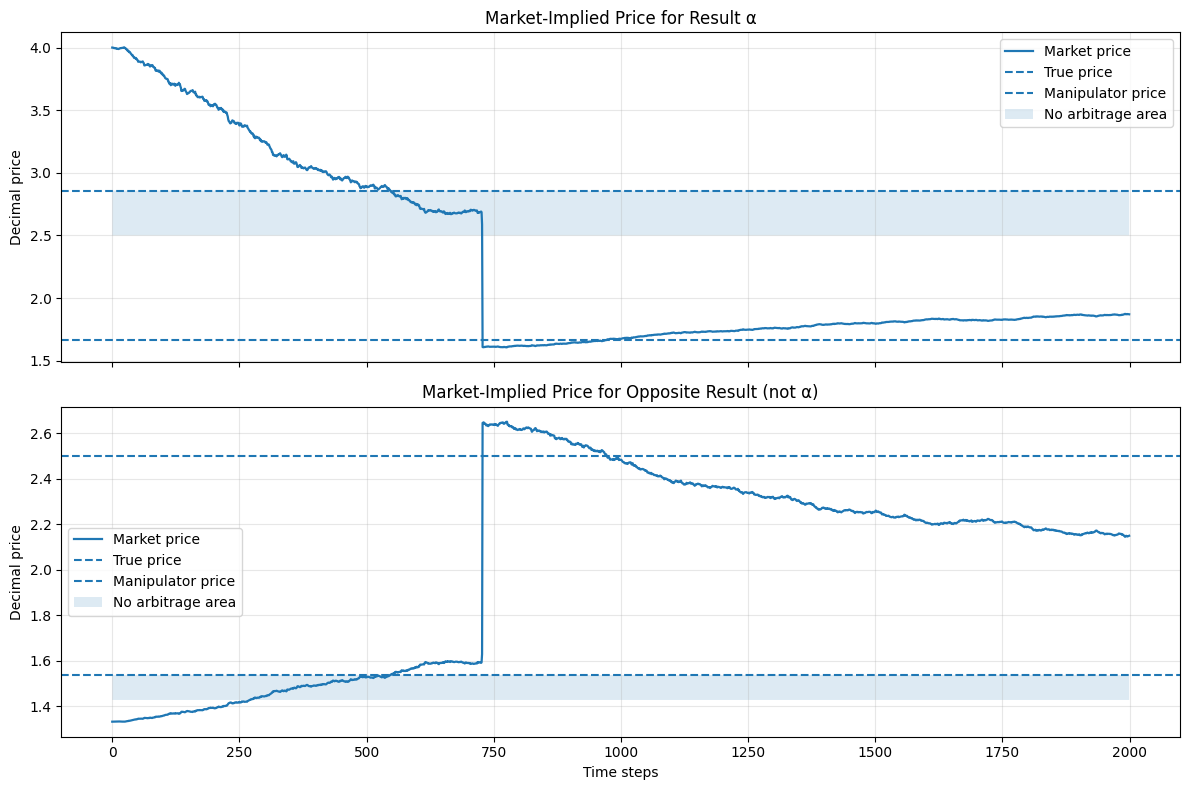

In [46]:
time = np.arange(len(prob_list))
fig, axes = plt.subplots(2, 1,figsize=(12, 8),sharex=True)

axes[0].plot(time,1/prob_list,label="Market price",linewidth=1.6)

axes[0].axhline(1/act,linestyle="--",linewidth=1.5,label="True price")
axes[0].axhline(1/(manip_prob),linestyle="--",linewidth=1.5,label="Manipulator price")
axes[0].fill_between(time,1 / (act + margin),1/act,alpha=0.15,label="No arbitrage area")

axes[0].set_ylabel("Decimal price")
axes[0].set_title("Market-Implied Price for Result α")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="best")


axes[1].plot(time,1/(1-prob_list),label="Market price",linewidth=1.6)

axes[1].axhline(1/(1-act),linestyle="--",linewidth=1.5,label="True price")
axes[1].axhline(1/(1-manip_prob),linestyle="--",linewidth=1.5,label="Manipulator price")
axes[1].fill_between(time,1 / (1 - act + margin),1/(1-act),alpha=0.15,label="No arbitrage area")

axes[1].set_xlabel("Time steps")
axes[1].set_ylabel("Decimal price")
axes[1].set_title("Market-Implied Price for Opposite Result (not α)")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="best")

plt.tight_layout()

The next step from here would be to have an even more realistic market with dummy traders, sharp traders and manipulators with all having different goals while the sharp estimations wouldn't perfectly allign. In this scenario many more interesting ideas can be explored such as signal reaction and creation for the sharp traders or even rapid volatility changes that captures the betting markets during inplay time. These concepts won't be further explored in this notebook since its target is just to show some generic ideas and toy models for the betting markets and not be more technical and complicated than that.

### Extra: A more realistic Beta($\alpha, \beta) $ based market:

Simple Beta-Based Prediction Market Simulation, a simplified prediction market for a binary event. The market belief is represented using a Beta distribution:

$$ p = \frac{a}{a+b} $$

where:

* (a) represents accumulated YES-side liquidity or evidence,
* (b) represents accumulated NO-side liquidity or evidence,
* (p) is the market-implied probability of the event occurring.

The model includes two types of traders:

1. **Dummy traders**
2. **Smart traders**


Dummy traders are uninformed traders. They do not know the true probability of the event and do not trade based on edge. Their stakes' distribution are following the market probability value at the time of betting and the stake size is randomly sampled from a normal distribution centered around zero:

$$
s_{\text{dummy}} \sim  | \mathcal{N}(0, \sigma_{\text{dummy}}^2) |
$$

Dummy traders create random market noise, while the smart traders know the true probability of the event.

They compare the true probability with the current market probability:

$$
\text{edge} = p_{\text{true}} - p_{\text{market}}
$$

If the edge is positive, smart traders buy YES.

If the edge is negative, smart traders buy NO.

Their stake is proportional to the edge:

$$
s_{\text{smart}} = k \cdot \text{edge}
$$

where (k) is the smart trader edge sensitivity.

This means smart traders trade more aggressively when the market is far from the true probability, and trade less when the market is close to fair value.

---

## Liquidity Depth

The parameter liquidity_depth controls how much each unit of stake moves the Beta parameters.

The actual market impact is:

$$
\text{impact} = \frac{|s|}{\text{liquidity depth}}
$$

Higher liquidity depth means the market is harder to move.

Lower liquidity depth means the same stake creates a larger probability movement.

---

## Decay

The model includes a decay factor applied to (a) and (b) each step:

$$
a_t \leftarrow d a_t
$$

$$
b_t \leftarrow d b_t
$$

where (d) is close to 1.

Decay prevents the market from becoming too rigid over time. Without decay, (a+b) grows forever and the probability becomes increasingly difficult to move.

A small floor is also used to keep (a) and (b) numerically valid.

In [60]:
def market_update2(a, b, stake, liquidity_depth=25.0, min_beta_value=1e-6):
    a = max(float(a), min_beta_value)
    b = max(float(b), min_beta_value)

    stake = float(stake)
    beta_impact = abs(stake) / liquidity_depth

    if stake > 0:
        a += beta_impact

    elif stake < 0:
        b += beta_impact

    a = max(a, min_beta_value)
    b = max(b, min_beta_value)

    prob, sigma = beta_stats(a, b)

    return a, b, prob

In [61]:
def market_simulation(true_prob=0.5,sim_n= 100,a = 10, b = 10.0, decay = 0.999, liquidity_depth = 25.0, market_chock = True,n_dummy = 100,
                      dummy_stake_mean = 0.0,dummy_stake_std = 0.30,max_dummy_stake = 3.0,dummy_edge_sensitivity = 1.,n_smart = 10,smart_edge_sensitivity = 30.0,
                      smart_stake_noise_std = 0.10,max_smart_stake = 3.0,max_no_shocks=2,shock_std = 0.10, margin = 0.0 ):

  min_beta_value = 1e-6

  if market_chock==True:
    no_shocks = rng.integers(1,max_no_shocks+1)
    time_of_shocks = rng.integers(1,int(0.80*sim_n),no_shocks)
    shocks = norm.rvs(0,shock_std,no_shocks)


  prob_list = np.zeros(sim_n)
  smart_net_stake_list = np.zeros(sim_n)
  dummy_net_stake_list = np.zeros(sim_n)
  a_list = np.zeros(sim_n)
  b_list = np.zeros(sim_n)
  dummy_total_stake_list = np.zeros(sim_n)
  n = 0

  prob, sigma = beta_stats(a, b)
  for i in range(sim_n):

    if np.isin(i,time_of_shocks):
      true_prob += shocks[n]
      n += 1

    a *= decay
    b *= decay

    a = max(a, min_beta_value)
    b = max(b, min_beta_value)

    dummy_net_stake = 0.0
    dummy_total_stake = 0.0

    for _ in range(n_dummy):

      edge = true_prob - prob
      buy_yes = rng.random() < a/(a+b)+edge*dummy_edge_sensitivity

      stake_size = abs(rng.normal(loc=dummy_stake_mean,scale=dummy_stake_std))

      stake_size = np.clip(stake_size,0.0,max_dummy_stake)

      if buy_yes:
        dummy_stake = stake_size
      else:
        dummy_stake = -stake_size

      a, b, prob = market_update2(
            a,b,dummy_stake,liquidity_depth=liquidity_depth)

      dummy_net_stake += dummy_stake
      dummy_total_stake += abs(dummy_stake)


    smart_net_stake = 0.0

    for _ in range(n_smart):

      prob, sigma = beta_stats(a, b)

      edge = true_prob - prob

      smart_stake = (smart_edge_sensitivity * (edge-margin)
            + rng.normal(0.0, smart_stake_noise_std))

      smart_stake = np.clip(
            smart_stake,-max_smart_stake,max_smart_stake)

      a, b, prob = market_update2(
            a,b,smart_stake,liquidity_depth=liquidity_depth)

      smart_net_stake += smart_stake


    prob, sigma = beta_stats(a, b)

    prob_list[i] = prob
    smart_net_stake_list[i] = smart_net_stake
    dummy_net_stake_list[i] = dummy_net_stake
    dummy_total_stake_list[i] = dummy_total_stake
    a_list[i] = a
    b_list[i] = b

  return prob_list,smart_net_stake_list,dummy_net_stake_list,dummy_total_stake_list,shocks,time_of_shocks

In [62]:
true_prob=0.7
prob_list,smart_net_stake_list,dummy_net_stake_list,dummy_total_stake_list,shocks,time_of_shocks = market_simulation(true_prob=true_prob,sim_n = 1000,max_no_shocks = 5,shock_std = 0.05)

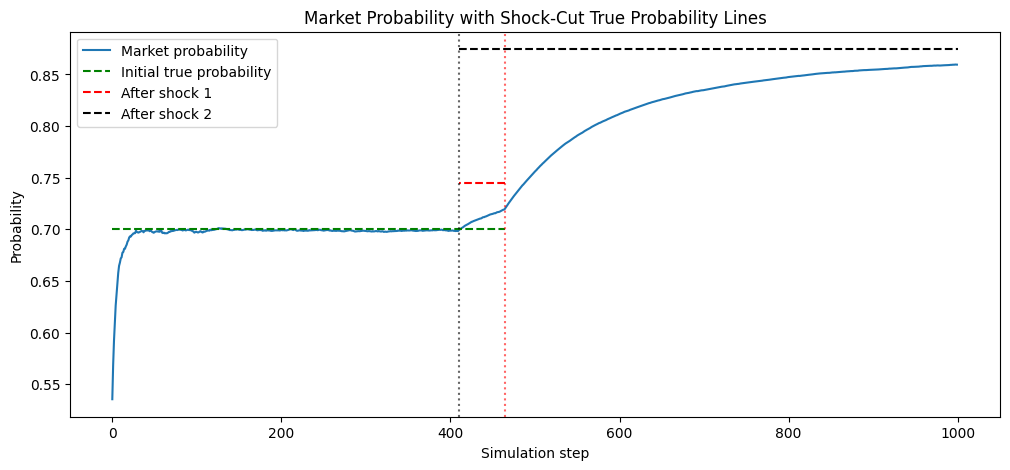

In [63]:
colors = ["red", "black", "gray"]

plt.figure(figsize=(12, 5))

plt.plot(prob_list, label="Market probability")

n_shocks = len(shocks)

# Initial true probability before first shock
if n_shocks > 0:
    plt.hlines(
        y=true_prob,
        xmin=0,
        xmax=time_of_shocks[0],
        color="green",
        linestyle="--",
        label="Initial true probability"
    )
else:
    plt.hlines(
        y=true_prob,
        xmin=0,
        xmax=len(prob_list),
        color="green",
        linestyle="--",
        label="Initial true probability"
    )

# Shock-adjusted true probability levels
shock_levels = true_prob + np.cumsum(shocks)

for i in range(n_shocks):

    xmin = time_of_shocks[i]

    if i + 1 < n_shocks:
        xmax = time_of_shocks[i + 1]
    else:
        xmax = len(prob_list)

    plt.hlines(
        y=shock_levels[i],
        xmin=xmin,
        xmax=xmax,
        color=colors[i % len(colors)],
        linestyle="--",
        label=f"After shock {i + 1}"
    )

    plt.axvline(
        x=time_of_shocks[i],
        color=colors[i % len(colors)],
        linestyle=":",
        alpha=0.6
    )

plt.xlabel("Simulation step")
plt.ylabel("Probability")
plt.title("Market Probability with Shock-Cut True Probability Lines")
plt.legend()
plt.show()

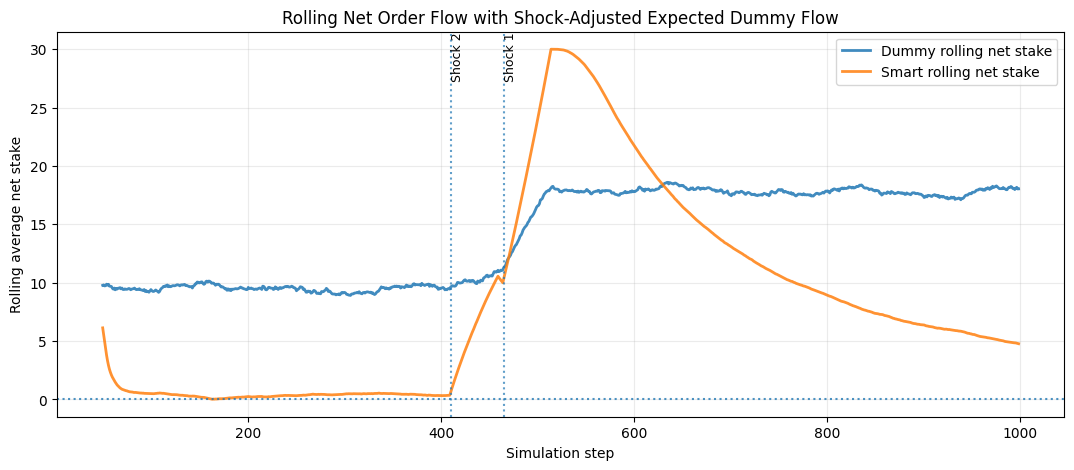

In [66]:
window = 50

dummy_rolling = np.convolve(dummy_net_stake_list,np.ones(window) / window,mode="valid")
smart_rolling = np.convolve(smart_net_stake_list,np.ones(window) / window,mode="valid")

dummy_total_rolling = np.convolve(dummy_total_stake_list,np.ones(window) / window,mode="valid")

x_rolling = np.arange(window - 1, sim_n)

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(x_rolling,dummy_rolling,label="Dummy rolling net stake",linewidth=2,alpha=0.85)
ax.plot(x_rolling,smart_rolling,label="Smart rolling net stake",linewidth=2,alpha=0.85)
ax.axhline(0,linestyle=":",linewidth=1.5,alpha=0.8)


for j, (shock_time, shock_value) in enumerate(zip(time_of_shocks, shocks), start=1):
    ax.axvline(shock_time,linestyle=":",alpha=0.7)

    ax.text(shock_time,ax.get_ylim()[1],f" Shock {j}",rotation=90,verticalalignment="top",fontsize=9)

ax.set_xlabel("Simulation step")
ax.set_ylabel("Rolling average net stake")
ax.set_title("Rolling Net Order Flow with Shock-Adjusted Expected Dummy Flow")

ax.grid(True, alpha=0.25)
ax.legend(loc="best")

plt.show()